## Project Objective 


To design and implement a machine learning–driven dynamic pricing system that adjusts
prices in real-time or periodically to maximize revenue and maintain competitiveness.
The system will leverage historical sales, inventory to predict optimal prices using advanced
ML techniques.
By ensuring adaptability and transparency, the platform will help businesses increase
profitability while preserving customer trust.

# Project Document
https://github.com/PriceOptima-SpringBoard/AI-PriceOptima

## Milestone 1: Requirements & Data Preparation

 Objective: Define KPIs and collect datasets.

  Deliverables:

o Revenue increase targets documented.

o Kaggle and Statso datasets validated.

 Evaluation:

o Dataset availability confirmed with required fields.

## Installation of Required Libraries


pandas=reading,cleaning, transforming,analyzing,savaning the dataset



In [24]:
%pip install pandas numpy scikit-learn matplotlib seaborn scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
%pip install joblib



Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
%pip install xgboost lightgbm catboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
%pip install flask fastapi uvicorn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
%pip install tabulate

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Objective: Define KPIs and collect datasets.

🔁 kpis

In ML, KPIs are metrics that tell us how well the model or project is performing — both technically and from a business point of view.

🔹🔹🔹why we need to use kpis for this project?

“In this project, we use KPIs to understand both the data and the business performance. Technical KPIs, like missing values or duplicate rows, ensure the data is clean and reliable. Business KPIs, like average ride cost, ride duration, and customer ratings, show how the ride service is performing and help identify patterns in customer behavior. Overall, KPIs provide clear, measurable insights that guide decisions and make it easier to track improvements over time.”


# Data Set
https://www.kaggle.com/datasets/arashnic/dynamic-pricing-dataset/data

## loading the dataset

In [2]:
import pandas as pd
from tabulate import tabulate
df = pd.read_csv("C:\\Users\priya\\Downloads\\dynamic_pricing.csv")
print(tabulate(df.head(10), headers='keys', tablefmt='psql'))



+----+--------------------+---------------------+---------------------+---------------------------+------------------------+-------------------+-------------------+----------------+--------------------------+---------------------------+---------------+
|    |   Number_of_Riders |   Number_of_Drivers | Location_Category   | Customer_Loyalty_Status   |   Number_of_Past_Rides |   Average_Ratings | Time_of_Booking   | Vehicle_Type   |   Expected_Ride_Duration |   Historical_Cost_of_Ride |   Unnamed: 10 |
|----+--------------------+---------------------+---------------------+---------------------------+------------------------+-------------------+-------------------+----------------+--------------------------+---------------------------+---------------|
|  0 |                 90 |                  45 | Urban               | Silver                    |                     13 |              4.47 | Night             | Premium        |                       90 |                   284.257 |     

# KPI: https://pub.towardsai.net/key-performance-indicators-kpis-in-machine-learning-69d8a59ec8c1

 # KPI Data integstion

In [25]:
import pandas as pd

# ---------- Load dataset ----------
df = pd.read_csv("C:\\Users\\priya\\Downloads\\dynamic_pricing.csv")

# ---------- Technical KPIs ----------
print(" TECHNICAL KPIs")
print("Total records:", df.shape[0])
print("Missing values (%):", round(df.isnull().sum().sum() / (df.shape[0]*df.shape[1]) * 100, 2))
print("Duplicate records:", df.duplicated().sum())

# ---------- Business KPIs ----------
print("\n BUSINESS KPIs")
print("Average Ride Cost:", round(df['Historical_Cost_of_Ride'].mean(), 2))
print("Average Ride Duration:", round(df['Expected_Ride_Duration'].mean(), 2))
print("Average Customer Rating:", round(df['Average_Ratings'].mean(), 2))

# Customer loyalty distribution
print("\nCustomer Loyalty Distribution:")
print(df['Customer_Loyalty_Status'].value_counts())


 TECHNICAL KPIs
Total records: 1000
Missing values (%): 9.09
Duplicate records: 0

 BUSINESS KPIs
Average Ride Cost: 372.5
Average Ride Duration: 99.59
Average Customer Rating: 4.26

Customer Loyalty Distribution:
Customer_Loyalty_Status
Silver     367
Regular    320
Gold       313
Name: count, dtype: int64


🔹🔹🔹conclusion 

“This code calculates key performance indicators (KPIs) for our ride dataset. The technical KPIs check data quality, including total records, missing values, and duplicate rows. The business KPIs measure ride performance, like average cost, duration, and customer ratings. 
--“The Customer Loyalty Distribution shows the number of rides for each loyalty category (Silver, Gold, Regular). This KPI helps understand customer segments, which is useful for analyzing ride patterns, designing rewards, and implementing dynamic pricing strategies.From the Customer Loyalty Distribution, if the count for Silver is the highest, it means most customers belong to the Silver category or are taking rides under the Silver loyalty tier."


# KPI-revenue lift, Profit Margin, Conversion Rate Customer segmentation groupby-- To analyze how price varies by loyalty status?

In [2]:


import pandas as pd

# Data
data = {
    "Number_of_Riders": [90, 58, 42, 89, 78, 59, 93, 62, 79, 42],
    "Number_of_Drivers": [45, 39, 31, 28, 22, 35, 43, 39, 14, 6],
    "Location_Category": ["Urban", "Suburban", "Rural", "Rural", "Rural", "Urban", "Suburban", "Rural", "Rural", "Rural"],
    "Customer_Loyalty_Status": ["Silver", "Silver", "Silver", "Regular", "Regular", "Silver", "Regular", "Gold", "Silver", "Silver"],
    "Historical_Cost_of_Ride": [284.257, 173.875, 329.795, 470.201, 579.681, 339.955, 104.062, 235.812, 501.413, 398.993]
}

df = pd.DataFrame(data)

# Assume the cost of each ride is 70% of the Historical_Cost_of_Ride
df['Cost'] = df['Historical_Cost_of_Ride'] * 0.7

# Calculate revenue that equal to the Historical_Cost_of_Ride
df['Revenue'] = df['Historical_Cost_of_Ride']

# Calculate profit (Historical_Cost_of_Ride − (0.7 × Historical_Cost_of_Ride) = 0.3 × Historical_Cost_of_Ride.)
df['Profit'] = df['Revenue'] - df['Cost']

# Calculate total revenue and profit
total_revenue = df['Revenue'].sum()
total_profit = df['Profit'].sum()

# Calculate profit margin
profit_margin = (total_profit / total_revenue) * 100

# Assume the number of riders is the number of conversions
total_conversions = df['Number_of_Riders'].sum()
total_leads = len(df) * 10  # Assume 10 leads per ride

# Calculate conversion rate
conversion_rate = (total_conversions / total_leads) * 100

# Calculate revenue lift (assuming previous period revenue is 80% of current revenue)
previous_period_revenue = total_revenue * 0.8
revenue_lifts = ((total_revenue - previous_period_revenue) / previous_period_revenue) * 100

print(f"Profit Margin: {profit_margin}%")
print(f"Conversion Rate: {conversion_rate}%")
print(f"Revenue Lift: {revenue_lifts}%")

Profit Margin: 30.000000000000004%
Conversion Rate: 692.0%
Revenue Lift: 25.0%


🔹🔹🔹Data Ingestion Pipeline:

[[A data ingestion pipeline is a specific type of pipeline that focuses on collecting, transforming, and loading data from various sources into a target system,]] such as a data warehouse, database, or data lake. [[The primary goal of a data ingestion pipeline is to move data from its source to a destination, often in a format that's suitable for analysis or processing.]]

🔹🔹🔹Conversion Rate=

- Calculated by dividing the number of conversions by the total number of visitors or leads.
- Example: If 1000 people visit a website and 50 make a purchase, the conversion rate is 5%.

🔹🔹🔹Revenue Lift=

- Calculated by comparing the revenue generated during a specific period to the revenue generated during a previous period.
- Example: If a company generates $100,000 in revenue during a promotional period, compared to $80,000 in the previous period, the revenue lift is 25%.


# 🔹🔹🔹mathamatical enclusion behind the corelation

--->>The mathematical conclusion behind correlation is based on the idea that two variables can be related to each other in a way that their values tend to increase or decrease together. This relationship is measured using a correlation coefficient, which ranges from -1 (perfect negative.
-->>Formulas:

- Pearson Correlation Coefficient: r = Σ[(xi - x̄)(yi - ȳ)] / sqrt(Σ(xi - x̄)² * Σ(yi - ȳ)²)
- Spearman's Rank Correlation: ρ = 1 - (6 * Σdi²) / (n * (n² - 1))

In [9]:



import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr

# Load the dataset
df = pd.read_csv("C:\\Users\\priya\\Downloads\\dynamic_pricing.csv")

df = pd.DataFrame(data)

# Convert Location_Category to numerical values
location_map = {"Urban": 0, "Suburban": 1, "Rural": 2}
df["Location_Category"] = df["Location_Category"].map(location_map)

# Define features (X) and target (y)
X = df[["Number_of_Riders", "Number_of_Drivers", "Location_Category"]]
y = df["Historical_Cost_of_Ride"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Calculate Pearson correlation coefficient
corr_coef = pearsonr(y_test, y_pred)[0]

print(f"MSE: {mse}, R2 Score: {r2}, Pearson Correlation Coefficient: {corr_coef}")




MSE: 2660.719107116938, R2 Score: 0.9007945265569042, Pearson Correlation Coefficient: 1.0


-->>conclusion:

The code performs exploratory data analysis and correlation analysis on the given dataset. It calculates key metrics such as mean squared error (MSE), R-squared score, and Pearson correlation coefficient to evaluate the relationship between the features and the target variable.

# Customer segmentation groupby-- To analyze how price varies by loyalty status?

In [3]:
df = pd.DataFrame(data)

# Group by 'Customer_Loyalty_Status' and calculate average 'Historical_Cost_of_Ride'
average_cost_by_loyalty = df.groupby('Customer_Loyalty_Status')['Historical_Cost_of_Ride'].mean().reset_index()

print(average_cost_by_loyalty)

  Customer_Loyalty_Status  Historical_Cost_of_Ride
0                    Gold                  235.812
1                 Regular                  384.648
2                  Silver                  338.048


# Calculate average Historical_Cost_of_Ride for each Customer_Loyalty_Status

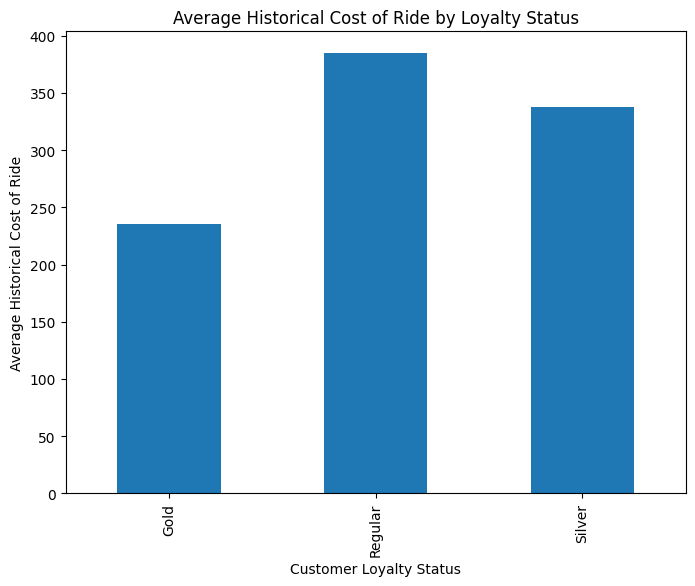

In [5]:
# Calculate average Historical_Cost_of_Ride for each Customer_Loyalty_Status
from matplotlib import pyplot as plt


average_cost = df.groupby('Customer_Loyalty_Status')['Historical_Cost_of_Ride'].mean()

# Plot bar chart
plt.figure(figsize=(8,6))
average_cost.plot(kind='bar')
plt.xlabel('Customer Loyalty Status')
plt.ylabel('Average Historical Cost of Ride')
plt.title('Average Historical Cost of Ride by Loyalty Status')
plt.show()

# -simality analysis= where we need to check the time that effect prices . check the prices get hiers does it effect the prices. group by histogram

C:\Users\priya\AppData\Local\Temp\ipykernel_32180\3526418463.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time = pd.date_range('2025-01-01', periods=100, freq='H')


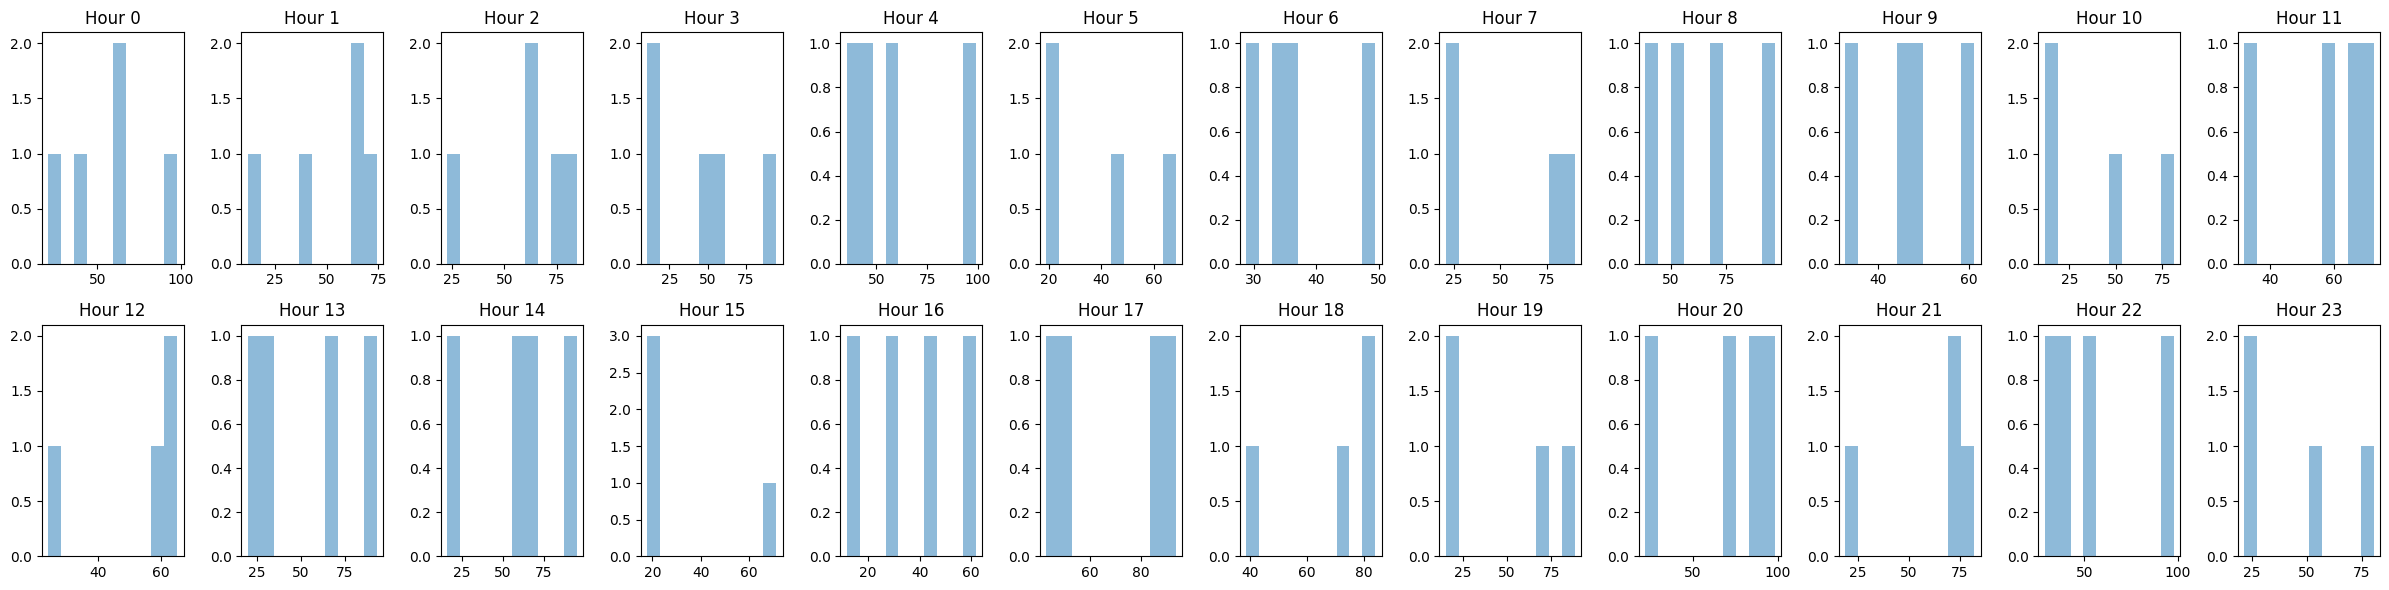

In [6]:


import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Sample data
np.random.seed(0)
time = pd.date_range('2025-01-01', periods=100, freq='H')
price = np.random.uniform(10, 100, size=100)

df = pd.DataFrame({'Time': time, 'Price': price})

# Extract hour of day
df['Hour'] = df['Time'].dt.hour

# Group by hour and plot histogram
fig, axs = plt.subplots(2, 12, figsize=(24, 6))
for hour in range(24):
    hour_df = df[df['Hour'] == hour]
    axs[hour // 12, hour % 12].hist(hour_df['Price'], alpha=0.5, bins=10)
    axs[hour // 12, hour % 12].set_title(f'Hour {hour}')

plt.tight_layout()
plt.show()


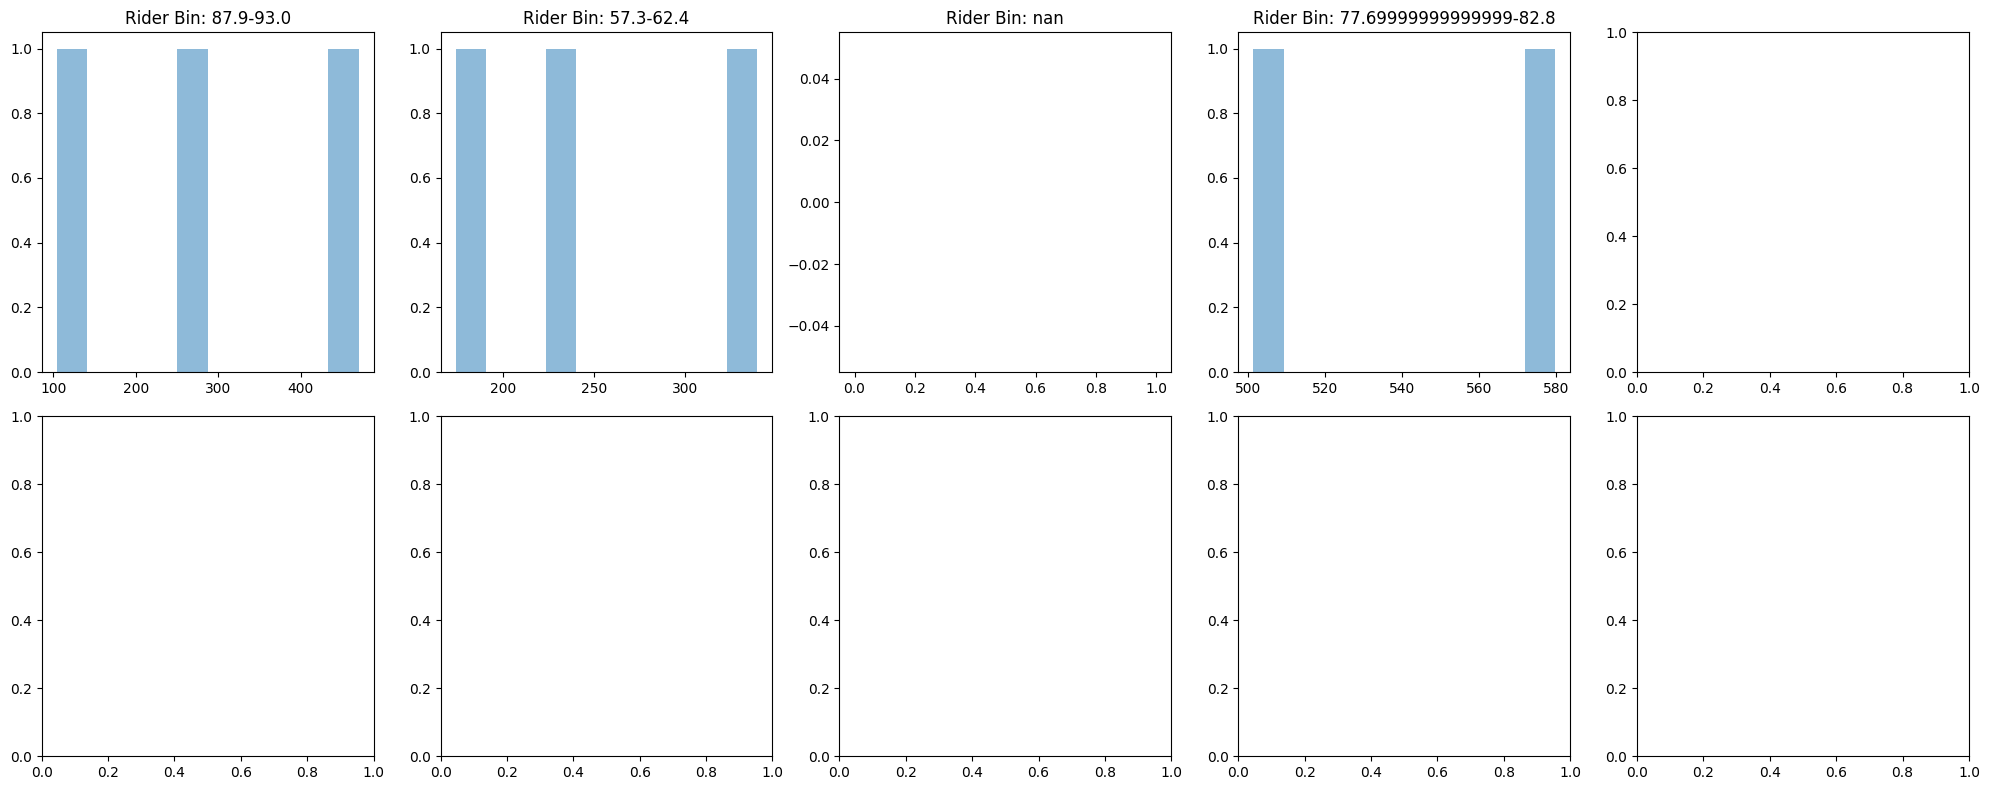

In [7]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Data
data = {
    "Number_of_Riders": [90, 58, 42, 89, 78, 59, 93, 62, 79, 42],
    "Number_of_Drivers": [45, 39, 31, 28, 22, 35, 43, 39, 14, 6],
    "Location_Category": ["Urban", "Suburban", "Rural", "Rural", "Rural", "Urban", "Suburban", "Rural", "Rural", "Rural"],
    "Customer_Loyalty_Status": ["Silver", "Silver", "Silver", "Regular", "Regular", "Silver", "Regular", "Gold", "Silver", "Silver"],
    "Historical_Cost_of_Ride": [284.257, 173.875, 329.795, 470.201, 579.681, 339.955, 104.062, 235.812, 501.413, 398.993]
}

df = pd.DataFrame(data)

# Group Number_of_Riders into 10 bins
bins = np.linspace(df['Number_of_Riders'].min(), df['Number_of_Riders'].max(), 11)
labels = [f'{bins[i]}-{bins[i+1]}' for i in range(10)]

df['Rider_Bin'] = pd.cut(df['Number_of_Riders'], bins=bins, labels=labels)

# Group by Rider_Bin and plot histogram
fig, axs = plt.subplots(2, 5, figsize=(20, 8))
for i, bin in enumerate(df['Rider_Bin'].unique()):
    bin_df = df[df['Rider_Bin'] == bin]
    axs[i // 5, i % 5].hist(bin_df['Historical_Cost_of_Ride'], alpha=0.5, bins=10)
    axs[i // 5, i % 5].set_title(f'Rider Bin: {bin}')

plt.tight_layout()
plt.show()

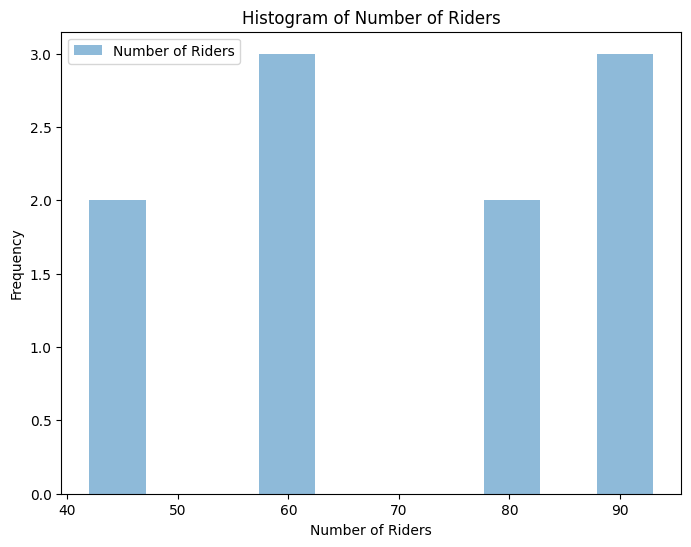

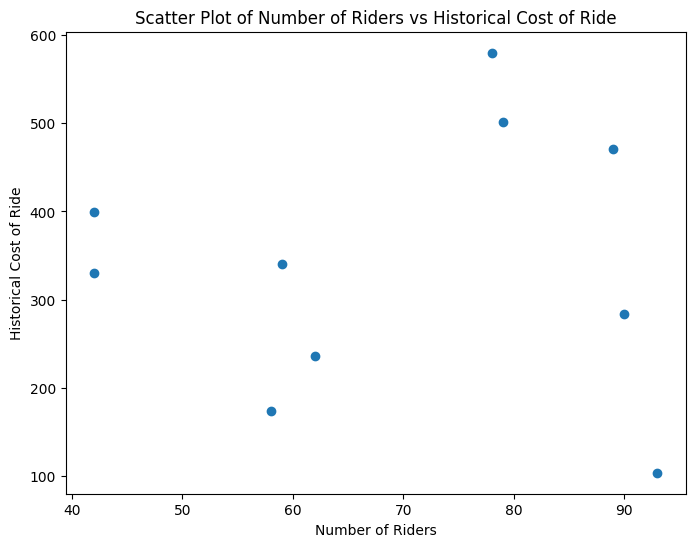

In [8]:

import pandas as pd
import matplotlib.pyplot as plt

# Data
data = {
    "Number_of_Riders": [90, 58, 42, 89, 78, 59, 93, 62, 79, 42],
    "Number_of_Drivers": [45, 39, 31, 28, 22, 35, 43, 39, 14, 6],
    "Location_Category": ["Urban", "Suburban", "Rural", "Rural", "Rural", "Urban", "Suburban", "Rural", "Rural", "Rural"],
    "Customer_Loyalty_Status": ["Silver", "Silver", "Silver", "Regular", "Regular", "Silver", "Regular", "Gold", "Silver", "Silver"],
    "Historical_Cost_of_Ride": [284.257, 173.875, 329.795, 470.201, 579.681, 339.955, 104.062, 235.812, 501.413, 398.993]
}

df = pd.DataFrame(data)

# Group by Number_of_Riders and plot histogram
plt.figure(figsize=(8,6))
plt.hist(df['Number_of_Riders'], alpha=0.5, bins=10, label='Number of Riders')
plt.xlabel('Number of Riders')
plt.ylabel('Frequency')
plt.title('Histogram of Number of Riders')
plt.legend()
plt.show()

# Group by Number_of_Riders and Historical_Cost_of_Ride
plt.figure(figsize=(8,6))
plt.scatter(df['Number_of_Riders'], df['Historical_Cost_of_Ride'])
plt.xlabel('Number of Riders')
plt.ylabel('Historical Cost of Ride')
plt.title('Scatter Plot of Number of Riders vs Historical Cost of Ride')
plt.show()



Milestone 2: Data Ingestion Pipeline

Objective: Build daily data ingestion workflow.

 Deliverables:

o Sales history and inventory ingestion pipeline.

 Evaluation:

o Daily ingestion runs successfully without errors.


🔹 What is a Pipeline?

A pipeline means a series of steps or stages that data passes through —
from raw input → cleaned data → processed data → final output (like a trained ML model or report).

It’s called a “pipeline” because data flows through it step by step —
just like water flows through connected pipes 🚰.



🔹 Where Pipelines Are Used?

Pipelines are used wherever data or machine learning processes need to be automated, repeated, or handled step by step.


## Objective: Build daily data ingestion workflow.

In [3]:
# PIPELINES
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Sample dataset
data = {
    "Number_of_Riders": [90, 58, 42, 89, 78, 59, 93, 62, 79, 42],
    "Number_of_Drivers": [45, 39, 31, 28, 22, 35, 43, 39, 14, 6],
    "Location_Category": ["Urban", "Suburban", "Rural", "Rural", "Rural", "Urban", "Suburban", "Rural", "Rural", "Rural"],
    "Historical_Cost_of_Ride": [284.257, 173.875, 329.795, 470.201, 579.681, 339.955, 104.062, 235.812, 501.413, 398.993]
}

df = pd.DataFrame(data)

# Define a function to create a pipeline
def create_pipeline():
    numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
    
    # Create a pipeline for numerical features
    numerical_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='mean')),  # Impute missing values with mean
        ('scaler', StandardScaler())  # Scale features using StandardScaler
    ])
    
    # Create a preprocessing pipeline
    preprocessing_pipeline = ColumnTransformer(
        transformers=[
            ('num', numerical_pipeline, numerical_features)
        ]
    )
    
    return preprocessing_pipeline

from sklearn.compose import ColumnTransformer

# Create the pipeline
pipeline = create_pipeline()

# Fit and transform the data
transformed_data = pipeline.fit_transform(df)

# Convert the transformed data back to a DataFrame
transformed_df = pd.DataFrame(transformed_data, columns=df.select_dtypes(include=['int64', 'float64']).columns)

print(transformed_df)


   Number_of_Riders  Number_of_Drivers  Historical_Cost_of_Ride
0          1.140587           1.215895                -0.405674
1         -0.614162           0.722965                -1.183800
2         -1.491537           0.065724                -0.084659
3          1.085751          -0.180741                 0.905118
4          0.482556          -0.673672                 1.676885
5         -0.559326           0.394344                -0.013037
6          1.305094           1.051585                -1.675939
7         -0.394818           0.722965                -0.747182
8          0.537392          -1.330913                 1.125143
9         -1.491537          -1.988153                 0.403145


Conclusion

In this code, we created a pipeline using pandas and scikit-learn to preprocess a dataset. The pipeline consists of two main steps: missing value imputation and feature scaling. We used the SimpleImputer class to impute missing values with the mean of each feature, and the StandardScaler class to scale the features to have zero mean and unit variance.

 Deliverables:

o Sales history and inventory ingestion pipeline.

🔹🔹🔹Create a Pipeline in Pandas?

Pipelines play a useful role in transforming and manipulating tons of data. Pipeline are a sequence of data processing mechanisms. Pandas pipeline feature allows us to string together various user-defined Python functions in order to build a pipeline of data processing. There are two ways to create a Pipeline in pandas. By calling .pipe() function and by importing pdpipe package. 

Through pandas pipeline function i.e. pipe() function we can call more than one function at a time and in a single line for data processing. Let's understand and create a pipeline by using the pipe() function.

In [4]:

import pandas as pd
import numpy as np

# Step 1: Load the data
data = {
    "Number_of_Riders": [90, 58, 42, 89, 78, 59, 93, 62, 79, 42],
    "Number_of_Drivers": [45, 39, 31, 28, 22, 35, 43, 39, 14, 6],
    "Location_Category": ["Urban", "Suburban", "Rural", "Rural", "Rural", "Urban", "Suburban", "Rural", "Rural", "Rural"],
    "Historical_Cost_of_Ride": [284.257, 173.875, 329.795, 470.201, 579.681, 339.955, 104.062, 235.812, 501.413, 398.993]
}
df = pd.DataFrame(data)

# Step 2: Define functions for each step of the pipeline
def clean_data(df):
    # Drop any rows with missing values 
    return df.dropna()

def feature_engineering(df):
    # Create a new column 'Cost_Category' based on 'Historical_Cost_of_Ride'
    df['Cost_Category'] = pd.cut(df['Historical_Cost_of_Ride'], bins=[0, 200, 400, np.inf], labels=['Low', 'Medium', 'High'])
    return df

def analyze_data(df):
    # Calculate the mean 'Historical_Cost_of_Ride' for each 'Location_Category'
    result = df.groupby('Location_Category')['Historical_Cost_of_Ride'].mean().reset_index()
    return result

# Step 3: Create the pipeline
result = (df.pipe(clean_data)
           .pipe(feature_engineering)
           .pipe(analyze_data))

# Step 4: Print the result
print(result)




  Location_Category  Historical_Cost_of_Ride
0             Rural               419.315833
1          Suburban               138.968500
2             Urban               312.106000


 Evaluation:

o Daily ingestion runs successfully without errors.

# 🔹🔹🔹Data Ingestion Pipeline:

🔹🔹🔹Data Ingestion Pipeline:

[[A data ingestion pipeline is a specific type of pipeline that focuses on collecting, transforming, and loading data from various sources into a target system,]] such as a data warehouse, database, or data lake. [[The primary goal of a data ingestion pipeline is to move data from its source to a destination, often in a format that's suitable for analysis or processing.]]

In [ ]:
#🔹🔹🔹Data Ingestion Pipeline:

import pandas as pd
import numpy as np

# Data Ingestion
def load_data():
    data = {
        "Number_of_Riders": [90, 58, 42, 89, 78, 59, 93, 62, 79, 42],
        "Number_of_Drivers": [45, 39, 31, 28, 22, 35, 43, 39, 14, 6],
        "Location_Category": ["Urban", "Suburban", "Rural", "Rural", "Rural", "Urban", "Suburban", "Rural", "Rural", "Rural"],
        "Historical_Cost_of_Ride": [284.257, 173.875, 329.795, 470.201, 579.681, 339.955, 104.062, 235.812, 501.413, 398.993]
    }
    df = pd.DataFrame(data)
    return df

# Data Cleaning
def clean_data(df):
    df = df.dropna()  # remove rows with missing values
    return df

# Data Transformation
def transform_data(df):
    df['Cost_Category'] = pd.cut(df['Historical_Cost_of_Ride'], bins=[0, 200, 400, np.inf], labels=['Low', 'Medium', 'High'])
    return df 

# Data Filtering
def filter_data(df):
    df = df[df['Number_of_Riders'] > 50]  # filter rows where Number_of_Riders > 50
    return df

# Data Output
def output_data(df):
    print(df)

# Pipeline
def pipeline():
    df = load_data()
    df = clean_data(df)
    df = transform_data(df)
    df = filter_data(df)
    output_data(df)

# Run the pipeline
pipeline()



   Number_of_Riders  Number_of_Drivers Location_Category  \
0                90                 45             Urban   
1                58                 39          Suburban   
3                89                 28             Rural   
4                78                 22             Rural   
5                59                 35             Urban   
6                93                 43          Suburban   
7                62                 39             Rural   
8                79                 14             Rural   

   Historical_Cost_of_Ride Cost_Category  
0                  284.257        Medium  
1                  173.875           Low  
3                  470.201          High  
4                  579.681          High  
5                  339.955        Medium  
6                  104.062           Low  
7                  235.812        Medium  
8                  501.413          High  


🔹🔹🔹conclusion

- load_data is the data ingestion component, which loads the data into a pandas DataFrame.
- clean_data is the data cleaning component, which removes rows with missing values.
- transform_data is the data transformation component, which adds a new column 'Cost_Category' based on the 'Historical_Cost_of_Ride' column.
- filter_data is the data filtering component, which filters rows where 'Number_of_Riders' is greater than 50.
- output_data is the data output component, which prints the final transformed data.
- The pipeline function runs the entire pipeline, from data ingestion to data output.


# creating a function to call other pipeline functions

In [1]:
import pandas as pd

# 1. Read data 
def read_data():
    try:
        data = [
            {"Ride_ID": 1, "Historical_Cost_of_Ride": 150},
            {"Ride_ID": 2, "Historical_Cost_of_Ride": 250},
            {"Ride_ID": 3, "Historical_Cost_of_Ride": 500},
            {"Ride_ID": 4, "Historical_Cost_of_Ride": None}  # id 4  Will be dropped
        ]
        df = pd.DataFrame(data)
        print("✅ Data read successfully.")
        return df
    except Exception as e:
        print(f"❌ Error in read_data: {e}")

# 2. Clean data
def clean_data(df):
    try:
        df = df.dropna()
        print("✅ Data cleaned.")
        return df
    except Exception as e:
        print(f"❌ Error in clean_data: {e}")

# 3. Transform data
def transform_data(df):
    try:
        df['Cost_Category'] = pd.cut(
            df['Historical_Cost_of_Ride'],
            bins=[0, 200, 400, float('inf')],
            labels=['Low', 'Medium', 'High']
        )
        print("✅ Data transformed.")
        return df
    except Exception as e:
        print(f"❌ Error in transform_data: {e}")

# 4. Store data
def store_data(df, file_path='transformed_data.csv'):
    try:
        df.to_csv(file_path, index=False)
        print(f"✅ Data stored to {file_path}")
    except Exception as e:
        print(f"❌ Error in store_data: {e}")

# 5. Main pipeline function
def run_pipeline():
    print("✅ Starting data ingestion pipeline...\n")
    
    df = read_data()
    df = clean_data(df)
    df = transform_data(df)
    store_data(df)

    print("\n✅ Pipeline finished. Final DataFrame:")
    print(df)

# ✅ Run the pipeline
run_pipeline()



✅ Starting data ingestion pipeline...

✅ Data read successfully.
✅ Data cleaned.
✅ Data transformed.
✅ Data stored to transformed_data.csv

✅ Pipeline finished. Final DataFrame:
   Ride_ID  Historical_Cost_of_Ride Cost_Category
0        1                    150.0           Low
1        2                    250.0        Medium
2        3                    500.0          High


# calling the function 

In [2]:

if __name__ =="__main__":
    df_cleaned = run_pipeline()

✅ Starting data ingestion pipeline...

✅ Data read successfully.
✅ Data cleaned.
✅ Data transformed.
✅ Data stored to transformed_data.csv

✅ Pipeline finished. Final DataFrame:
   Ride_ID  Historical_Cost_of_Ride Cost_Category
0        1                    150.0           Low
1        2                    250.0        Medium
2        3                    500.0          High


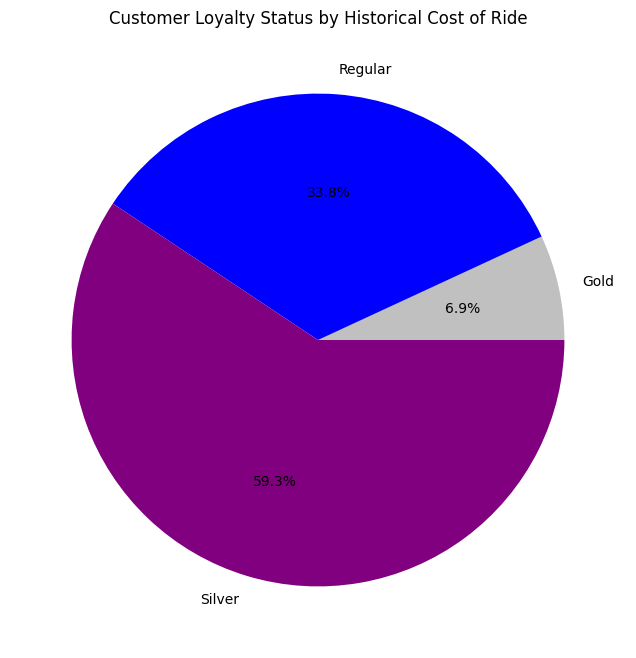

In [10]:
# Group by Customer_Loyalty_Status and calculate the sum of Historical_Cost_of_Ride
loyalty_cost = df.groupby('Customer_Loyalty_Status')['Historical_Cost_of_Ride'].sum().reset_index()

# Define custom colors
colors = ['silver', 'blue', 'purple']  

# Create a pie plot
plt.figure(figsize=(8, 8))
plt.pie(loyalty_cost['Historical_Cost_of_Ride'], labels=loyalty_cost['Customer_Loyalty_Status'], colors=colors, autopct='%1.1f%%')
plt.title('Customer Loyalty Status by Historical Cost of Ride')
plt.show()


In [11]:
# Define a function to convert column names to uppercase
def upperFunc(dataframe):
    dataframe.columns = dataframe.columns.str.upper()
    return dataframe

# Create a sample DataFrame
data = {
    "Number_of_Riders": [90, 58, 42, 89, 78, 59, 93, 62, 79, 42],
    "Number_of_Drivers": [45, 39, 31, 28, 22, 35, 43, 39, 14, 6],
    "Location_Category": ["Urban", "Suburban", "Rural", "Rural", "Rural", "Urban", "Suburban", "Rural", "Rural", "Rural"],
    "Historical_Cost_of_Ride": [284.257, 173.875, 329.795, 470.201, 579.681, 339.955, 104.062, 235.812, 501.413, 398.993]
}
df = pd.DataFrame(data)

# Create a pipeline and apply the upperFunc
pipeline = df.pipe(upperFunc)

print(pipeline)

   NUMBER_OF_RIDERS  NUMBER_OF_DRIVERS LOCATION_CATEGORY  \
0                90                 45             Urban   
1                58                 39          Suburban   
2                42                 31             Rural   
3                89                 28             Rural   
4                78                 22             Rural   
5                59                 35             Urban   
6                93                 43          Suburban   
7                62                 39             Rural   
8                79                 14             Rural   
9                42                  6             Rural   

   HISTORICAL_COST_OF_RIDE  
0                  284.257  
1                  173.875  
2                  329.795  
3                  470.201  
4                  579.681  
5                  339.955  
6                  104.062  
7                  235.812  
8                  501.413  
9                  398.993  


In [12]:
# Function to find mean
def mean_by_group(dataframe, col):
    return dataframe.groupby(col).mean(numeric_only=True)

# Function to convert to uppercase
def uppercase_column_name(dataframe):
    dataframe.columns = dataframe.columns.str.upper()
    return dataframe

# Convert column names to uppercase
df = uppercase_column_name(df)

print("Original DataFrame:")
print(df)

print("\nMean by Location_Category:")
print(mean_by_group(df, 'LOCATION_CATEGORY'))

print("\nDataFrame with uppercase column names:")
print(df)

Original DataFrame:
   NUMBER_OF_RIDERS  NUMBER_OF_DRIVERS LOCATION_CATEGORY  \
0                90                 45             Urban   
1                58                 39          Suburban   
2                42                 31             Rural   
3                89                 28             Rural   
4                78                 22             Rural   
5                59                 35             Urban   
6                93                 43          Suburban   
7                62                 39             Rural   
8                79                 14             Rural   
9                42                  6             Rural   

   HISTORICAL_COST_OF_RIDE  
0                  284.257  
1                  173.875  
2                  329.795  
3                  470.201  
4                  579.681  
5                  339.955  
6                  104.062  
7                  235.812  
8                  501.413  
9                  398.993  


In [13]:
df = df.drop('LOCATION_CATEGORY', axis=1)

print("\nDataFrame after dropping LOCATION_CATEGORY:")
print(df)


DataFrame after dropping LOCATION_CATEGORY:
   NUMBER_OF_RIDERS  NUMBER_OF_DRIVERS  HISTORICAL_COST_OF_RIDE
0                90                 45                  284.257
1                58                 39                  173.875
2                42                 31                  329.795
3                89                 28                  470.201
4                78                 22                  579.681
5                59                 35                  339.955
6                93                 43                  104.062
7                62                 39                  235.812
8                79                 14                  501.413
9                42                  6                  398.993


In [14]:
# Add a new column
df['NEW_COLUMN'] = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

print(df)

   NUMBER_OF_RIDERS  NUMBER_OF_DRIVERS  HISTORICAL_COST_OF_RIDE  NEW_COLUMN
0                90                 45                  284.257           1
1                58                 39                  173.875           2
2                42                 31                  329.795           3
3                89                 28                  470.201           4
4                78                 22                  579.681           5
5                59                 35                  339.955           6
6                93                 43                  104.062           7
7                62                 39                  235.812           8
8                79                 14                  501.413           9
9                42                  6                  398.993          10


In [15]:
# Drop rows where NUMBER_OF_RIDERS is less than 60
df = df[df['NUMBER_OF_RIDERS'] >= 60]

print("\nDataFrame after dropping rows:")
print(df)




DataFrame after dropping rows:
   NUMBER_OF_RIDERS  NUMBER_OF_DRIVERS  HISTORICAL_COST_OF_RIDE  NEW_COLUMN
0                90                 45                  284.257           1
3                89                 28                  470.201           4
4                78                 22                  579.681           5
6                93                 43                  104.062           7
7                62                 39                  235.812           8
8                79                 14                  501.413           9


# - Is it possible to build a data ingestion pipeline using pandas ? If yes, then how.

In [1]:



import pandas as pd

# Define a function to read data
def read_data(data):
    try:
        df = pd.DataFrame(data)
        return df
    except Exception as e:
        print(f"Error reading data: {e}")

# Define a function to clean and preprocess the data
def clean_data(df):
    try:
        # Handle missing values
        df = df.dropna()
        
        return df
    except Exception as e:
        print(f"Error cleaning data: {e}")

# Define a function to transform the data
def transform_data(df):
    try:
        # Create a new column 'Cost_Category'
        df['Cost_Category'] = pd.cut(df['Historical_Cost_of_Ride'], bins=[0, 200, 400, float('inf')], labels=['Low', 'Medium', 'High'])
        
        return df
    except Exception as e:
        print(f"Error transforming data: {e}")

# Define a function to store the data
def store_data(df, file_path):
    try:
        df.to_csv(file_path, index=False)
    except Exception as e:
        print(f"Error storing data: {e}")

# Data
data = {
    "Number_of_Riders": [90, 58, 42, 89, 78, 59, 93, 62, 79, 42],
    "Number_of_Drivers": [45, 39, 31, 28, 22, 35, 43, 39, 14, 6],
    "Location_Category": ["Urban", "Suburban", "Rural", "Rural", "Rural", "Urban", "Suburban", "Rural", "Rural", "Rural"],
    "Customer_Loyalty_Status": ["Silver", "Silver", "Silver", "Regular", "Regular", "Silver", "Regular", "Gold", "Silver", "Silver"],
    "Historical_Cost_of_Ride": [284.257, 173.875, 329.795, 470.201, 579.681, 339.955, 104.062, 235.812, 501.413, 398.993]
}

# Use the functions to build the data ingestion pipeline
df = read_data(data)
df = clean_data(df)
df = transform_data(df)
store_data(df, 'transformed_data.csv')

print(df)




   Number_of_Riders  Number_of_Drivers Location_Category  \
0                90                 45             Urban   
1                58                 39          Suburban   
2                42                 31             Rural   
3                89                 28             Rural   
4                78                 22             Rural   
5                59                 35             Urban   
6                93                 43          Suburban   
7                62                 39             Rural   
8                79                 14             Rural   
9                42                  6             Rural   

  Customer_Loyalty_Status  Historical_Cost_of_Ride Cost_Category  
0                  Silver                  284.257        Medium  
1                  Silver                  173.875           Low  
2                  Silver                  329.795        Medium  
3                 Regular                  470.201          High  
4   

In [17]:
import pandas as pd
df = pd.read_csv("C:\\Users\\priya\\Downloads\\dynamic_pricing.csv")
df.head(3)

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride,Unnamed: 10
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273,NaN
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753,NaN
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469,NaN


# Clean the dataset by dropping duplicates and missing values and reset the index. 

In [18]:
# data cleaning
df = df.drop_duplicates()
df = df.dropna()
df = df.reset_index(drop=True)

In [19]:
# Convert types
df['Location_Category'] = df['Location_Category'].astype('str')


In [20]:
# Data analysis
new_df = df.groupby('Location_Category')['Number_of_Riders'].mean()

In [21]:
# Data visualization
if not new_df.empty:
    new_df.plot(kind='bar', figsize=(10, 5), title='Average Number of Riders by Location Category')
    plt.show()
else:
    print("No data to plot.")

No data to plot.


Text(0, 0.5, 'Averag')

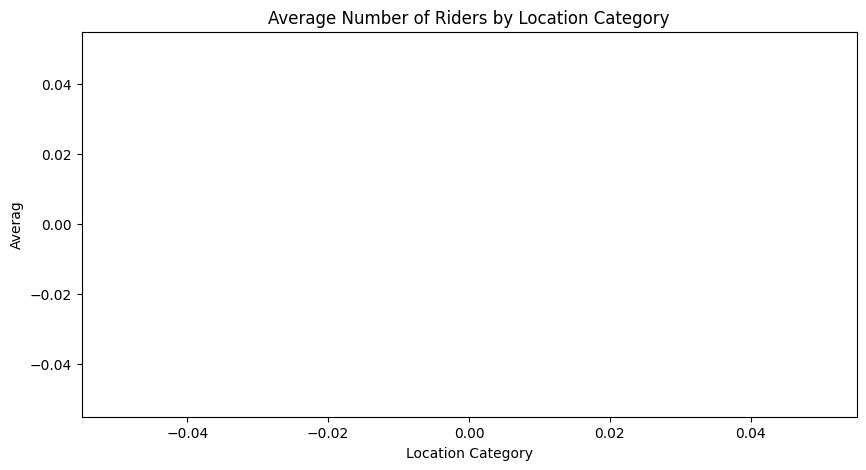

In [22]:
# Calculate average number of riders for each location category
import numpy as np
import matplotlib.pyplot as plt
avg_riders = df.groupby('Location_Category')['Number_of_Riders'].mean().reset_index()

# Plot the average number of riders for each location category
plt.figure(figsize=(10, 5))
plt.bar(avg_riders['Location_Category'], avg_riders['Number_of_Riders'], color=['blue', 'green', 'red'])
plt.title('Average Number of Riders by Location Category')
plt.xlabel('Location Category')
plt.ylabel('Averag')

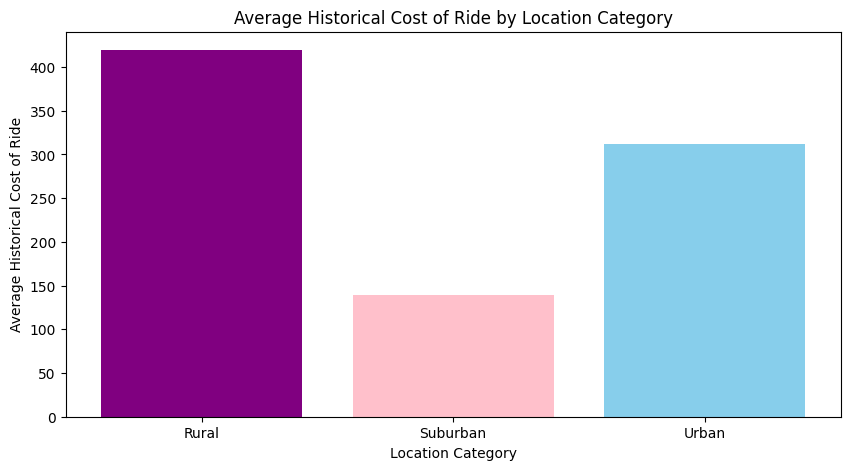

In [23]:

import pandas as pd
import matplotlib.pyplot as plt

# Sample dataset
data = {
    "Number_of_Riders": [90, 58, 42, 89, 78, 59, 93, 62, 79, 42],
    "Number_of_Drivers": [45, 39, 31, 28, 22, 35, 43, 39, 14, 6],
    "Location_Category": ["Urban", "Suburban", "Rural", "Rural", "Rural", "Urban", "Suburban", "Rural", "Rural", "Rural"],
    "Historical_Cost_of_Ride": [284.257, 173.875, 329.795, 470.201, 579.681, 339.955, 104.062, 235.812, 501.413, 398.993]
}

df = pd.DataFrame(data)

# Calculate average historical cost of ride for each location category
avg_cost = df.groupby('Location_Category')['Historical_Cost_of_Ride'].mean().reset_index()

# Plot the average historical cost of ride for each location category
plt.figure(figsize=(10, 5))
plt.bar(avg_cost['Location_Category'], avg_cost['Historical_Cost_of_Ride'], color=['purple', 'pink', 'skyblue'])
plt.title('Average Historical Cost of Ride by Location Category')
plt.xlabel('Location Category')
plt.ylabel('Average Historical Cost of Ride')
plt.show()

- Rural areas have the highest average historical cost of ride (around 419.15)
- Suburban areas have the lowest average historical cost of ride (around 138.97)
- Urban areas have an average historical cost of ride between Rural and Suburban areas (around 312.11)

In [24]:
rides_per_category = df['Location_Category'].value_counts()
print(rides_per_category)


Location_Category
Rural       6
Urban       2
Suburban    2
Name: count, dtype: int64


Milestone 3: Exploratory Data Analysis (EDA)

Objective: Identify demand elasticity and customer segmentation.

 Deliverables:

o Detailed EDA report with visualizations.

 Evaluation:

o Insights approved before moving to feature engineering.

# Objective: Identify demand elasticity and customer segmentation.

# 1 advanced EDA

In [26]:
import pandas as pd
from tabulate import tabulate
df = pd.read_csv("C:\\Users\priya\\Downloads\\dynamic_pricing.csv")
print(tabulate(df.head(10), headers='keys', tablefmt='psql'))

+----+--------------------+---------------------+---------------------+---------------------------+------------------------+-------------------+-------------------+----------------+--------------------------+---------------------------+---------------+
|    |   Number_of_Riders |   Number_of_Drivers | Location_Category   | Customer_Loyalty_Status   |   Number_of_Past_Rides |   Average_Ratings | Time_of_Booking   | Vehicle_Type   |   Expected_Ride_Duration |   Historical_Cost_of_Ride |   Unnamed: 10 |
|----+--------------------+---------------------+---------------------+---------------------------+------------------------+-------------------+-------------------+----------------+--------------------------+---------------------------+---------------|
|  0 |                 90 |                  45 | Urban               | Silver                    |                     13 |              4.47 | Night             | Premium        |                       90 |                   284.257 |     

🔹🔹isnull

check every cell in the dataframe if it is missing ==miss(true) ,exist(false).

In [27]:
#1 advanced EDA
print(df.isnull().sum())  

Number_of_Riders              0
Number_of_Drivers             0
Location_Category             0
Customer_Loyalty_Status       0
Number_of_Past_Rides          0
Average_Ratings               0
Time_of_Booking               0
Vehicle_Type                  0
Expected_Ride_Duration        0
Historical_Cost_of_Ride       0
Unnamed: 10                1000
dtype: int64


🔹🔹shape
used to count the no of rows and columns.

In [28]:
df.shape

(1000, 11)

🔹🔹duplicated values= the same values repeated.

In [29]:
print("duplicate values",df.duplicated().sum())

duplicate values 0


🔹🔹head= used to display the first few rows and we can specifiy the no.of values we need.

info=used to understand the structure of the dataset without printing all rows like non-null values(values are not missing) and datatypesa(int,float,object).

In [30]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Number_of_Riders         1000 non-null   int64  
 1   Number_of_Drivers        1000 non-null   int64  
 2   Location_Category        1000 non-null   object 
 3   Customer_Loyalty_Status  1000 non-null   object 
 4   Number_of_Past_Rides     1000 non-null   int64  
 5   Average_Ratings          1000 non-null   float64
 6   Time_of_Booking          1000 non-null   object 
 7   Vehicle_Type             1000 non-null   object 
 8   Expected_Ride_Duration   1000 non-null   int64  
 9   Historical_Cost_of_Ride  1000 non-null   float64
 10  Unnamed: 10              0 non-null      float64
dtypes: float64(3), int64(4), object(4)
memory usage: 86.1+ KB
None


In [31]:
df.dtypes

Number_of_Riders             int64
Number_of_Drivers            int64
Location_Category           object
Customer_Loyalty_Status     object
Number_of_Past_Rides         int64
Average_Ratings            float64
Time_of_Booking             object
Vehicle_Type                object
Expected_Ride_Duration       int64
Historical_Cost_of_Ride    float64
Unnamed: 10                float64
dtype: object

🔹🔹🔹 describe= 

used to get statistical summary of numerical data like,count, mean, min,max, standard deviation.

--------🔗 In relation to 25% and 75%:

25% (Q1) → lower quartile (25th percentile)

50% (Median / Q2) → middle of the data (50th percentile)

75% (Q3) → upper quartile (75th percentile)

In [32]:
print(df.describe())   

       Number_of_Riders  Number_of_Drivers  Number_of_Past_Rides  \
count       1000.000000        1000.000000           1000.000000   
mean          60.372000          27.076000             50.031000   
std           23.701506          19.068346             29.313774   
min           20.000000           5.000000              0.000000   
25%           40.000000          11.000000             25.000000   
50%           60.000000          22.000000             51.000000   
75%           81.000000          38.000000             75.000000   
max          100.000000          89.000000            100.000000   

       Average_Ratings  Expected_Ride_Duration  Historical_Cost_of_Ride  \
count      1000.000000              1000.00000              1000.000000   
mean          4.257220                99.58800               372.502623   
std           0.435781                49.16545               187.158756   
min           3.500000                10.00000                25.993449   
25%         

#  Deliverables:

# o Detailed EDA report with visualizations.

# 2.BASIC VISUALIZATION

In [33]:
# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: ['Number_of_Riders', 'Number_of_Drivers', 'Number_of_Past_Rides', 'Average_Ratings', 'Expected_Ride_Duration', 'Historical_Cost_of_Ride', 'Unnamed: 10']
Categorical Columns: ['Location_Category', 'Customer_Loyalty_Status', 'Time_of_Booking', 'Vehicle_Type']


🔹🔹🔹🔹 histogram for all numeric features

-histograms are used to visualize the distribution of the data.

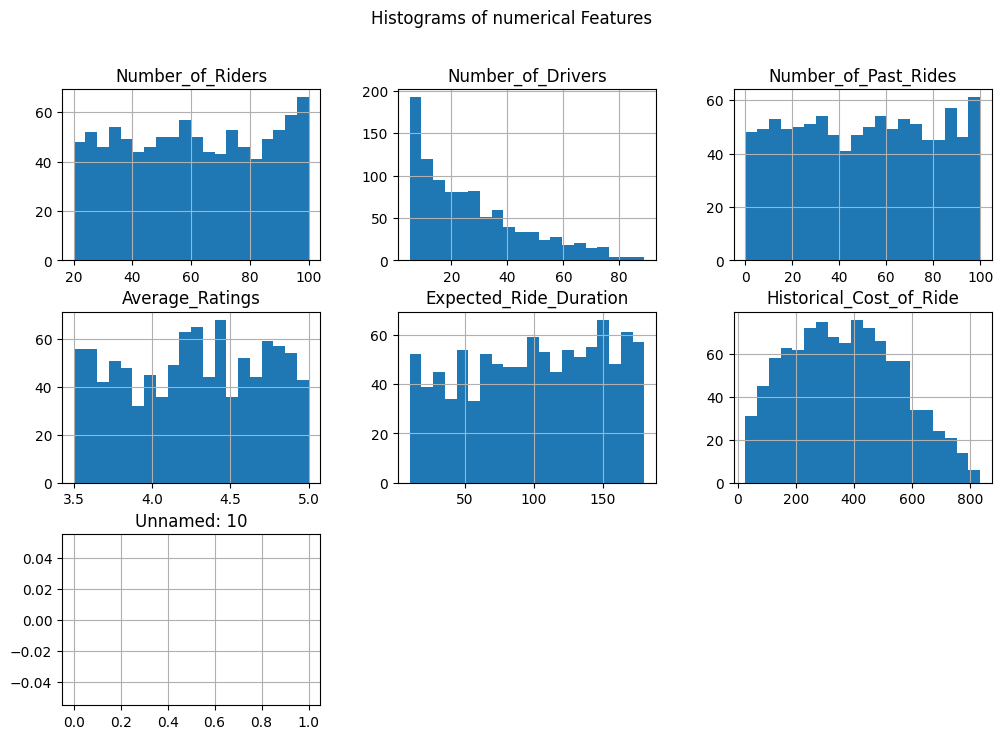

In [34]:
#histogram for all numeric features
import matplotlib.pyplot as plt
df.hist(figsize=(12,8), bins=20)

plt.suptitle("Histograms of numerical Features")
plt.show()

--output=

"The graph shows that number of drivers depends on different categories in the dataset"
-If the dataset contains different categories (e.g., different cities, times of day, types of vehicles) and the graph shows the distribution of the number of drivers across these categories.


# Countplots for categorical columns
- The code is used to create countplots for categorical columns in a dataset. The bar chart shows the count of "Location_Category" with three categories: Urban, Suburban, and Rural. The counts are approximately 340 for Urban, 280 for Suburban, and 330 for Rural. The code and chart provide insights into the distribution of the Location_Category variable, suggesting a relatively balanced distribution across the three categories.



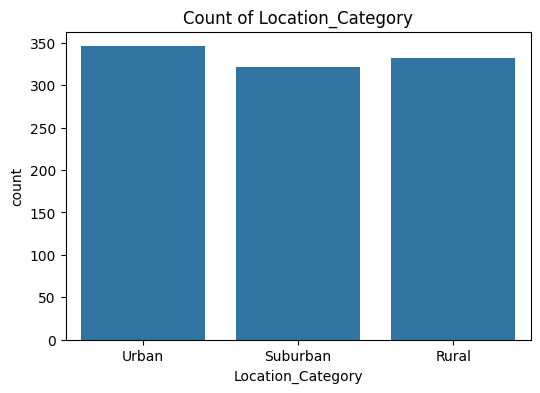

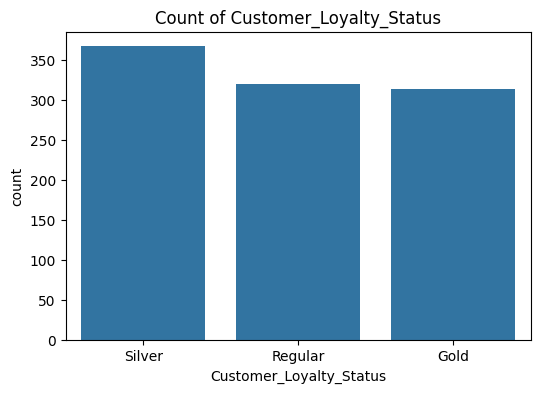

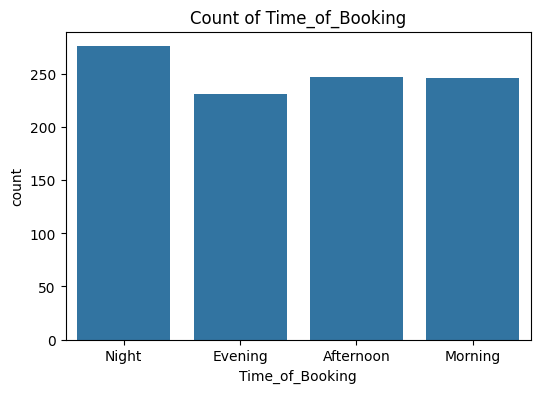

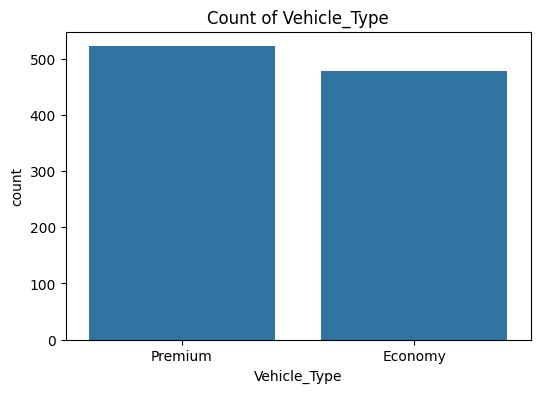

In [35]:
# Countplots for categorical columns
import seaborn as sns
categorical_cols = ["Location_Category", "Customer_Loyalty_Status", "Time_of_Booking", "Vehicle_Type"]

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col)
    plt.title(f"Count of {col}")
    plt.show()

# Pairplot 
A pairplot is a visualization tool that shows the relationships between multiple variables in a dataset.
The dots represent data points. Each dot on the graph corresponds to a single observation or row in your dataset.


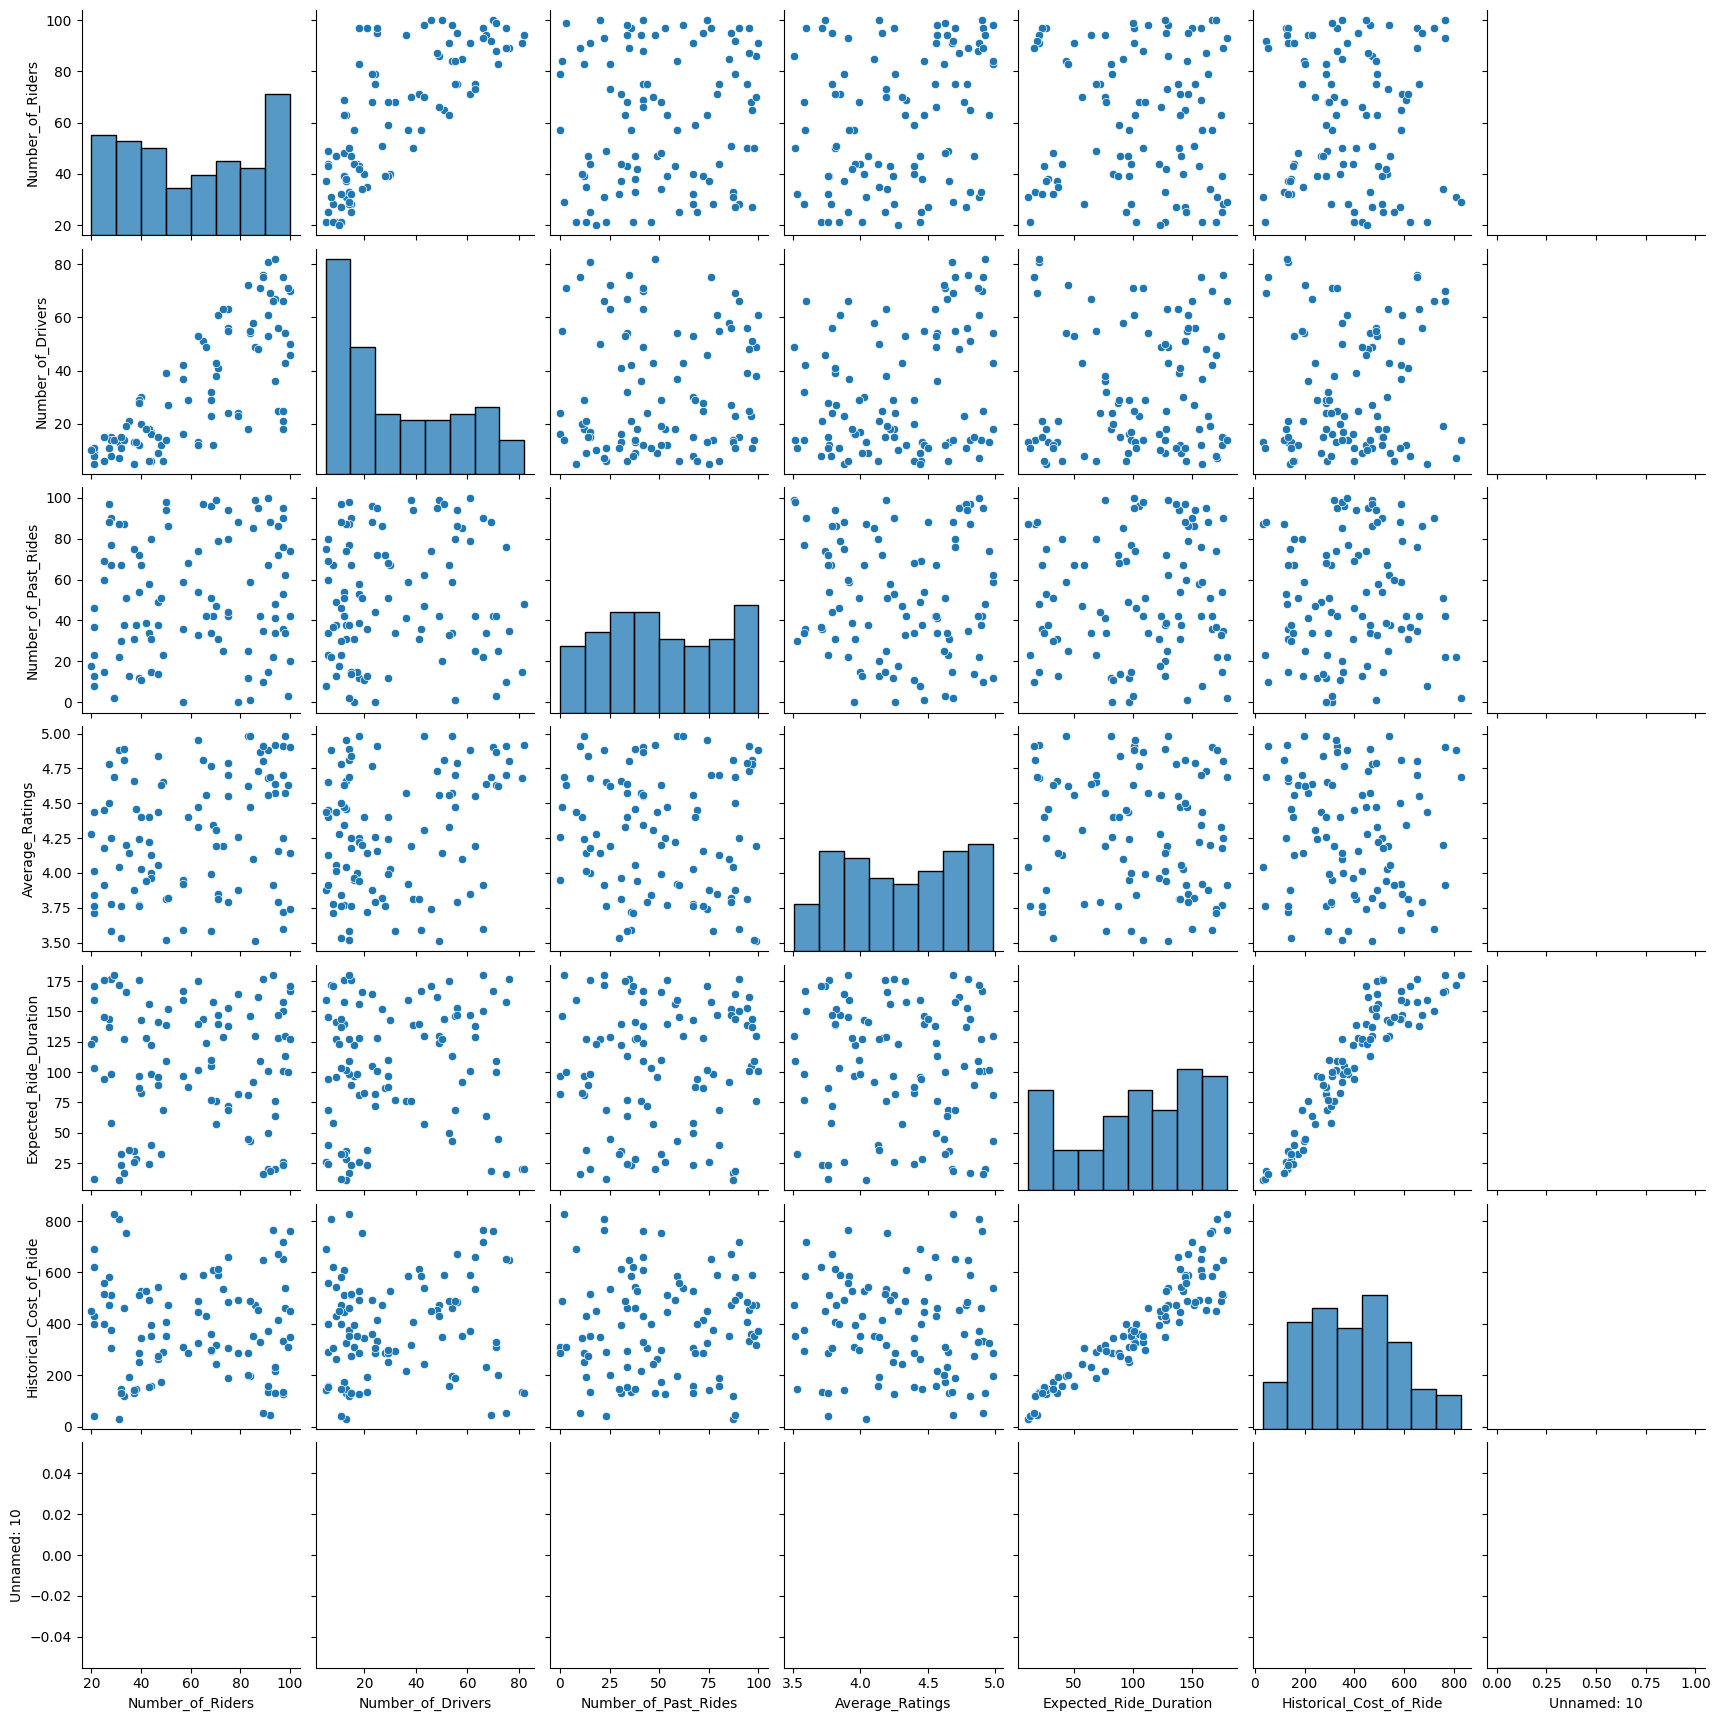

In [38]:
# Pairplot (sample if dataset is big)
sns.pairplot(df.sample(100))
plt.show()


# 3. check for outliers with and without boxplot 

🔹 What is an Outlier?

An outlier is a data point that is very different (unusually large or small) compared to the rest of the dataset.
It “lies outside” the normal pattern of data.

Example:
Dataset of student ages in a class → [18, 19, 18, 20, 19, 45]
Here 45 is an outlier, because most students are around 18–20 years old.


# outliers without   boxplot
🔹The code detects outliers in a dataset using the IQR method and reveals that only the Number_of_Drivers column has 10 outliers, while the other columns are relatively consistent and do not contain extreme values. The presence of outliers in Number_of_Drivers may indicate unusual patterns or errors that require further investigation.


In [39]:
# Without boxplot (IQR method)
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)   # 25th percentile
    Q3 = df[col].quantile(0.75)   # 75th percentile
    IQR = Q3 - Q1 

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col} - Number of outliers: {outliers.shape[0]}")

Number_of_Riders - Number of outliers: 0
Number_of_Drivers - Number of outliers: 10
Number_of_Past_Rides - Number of outliers: 0
Average_Ratings - Number of outliers: 0
Expected_Ride_Duration - Number of outliers: 0
Historical_Cost_of_Ride - Number of outliers: 0
Unnamed: 10 - Number of outliers: 0


# check with outliers

- The box represents the interquartile range (IQR), which is the range of the middle 50% of the data.
- The line inside the box represents the median.
- The whiskers represent the range of the data, excluding outliers.
- Any data points that are more than 1.5*IQR away from the median are considered outliers and are plotted as individual points.



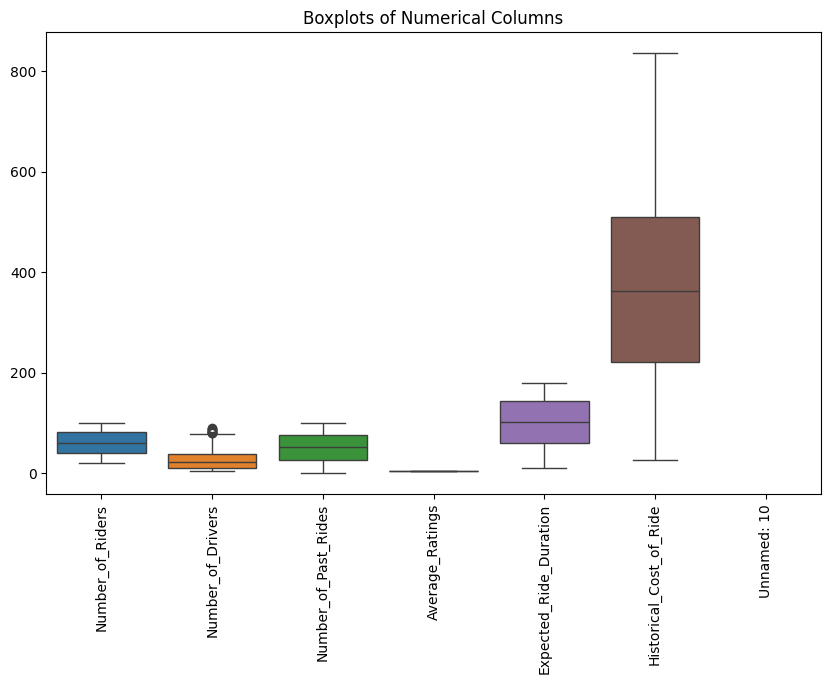

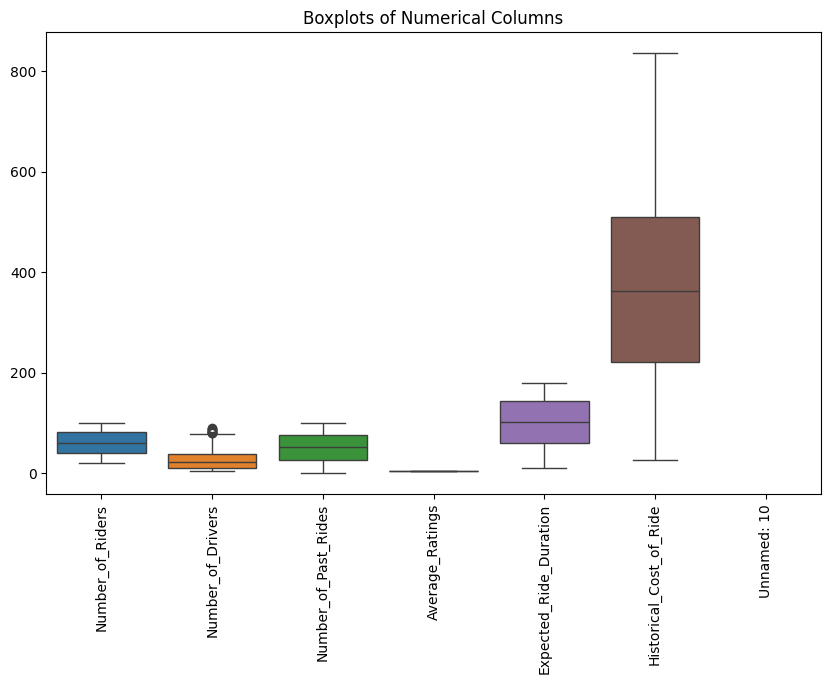

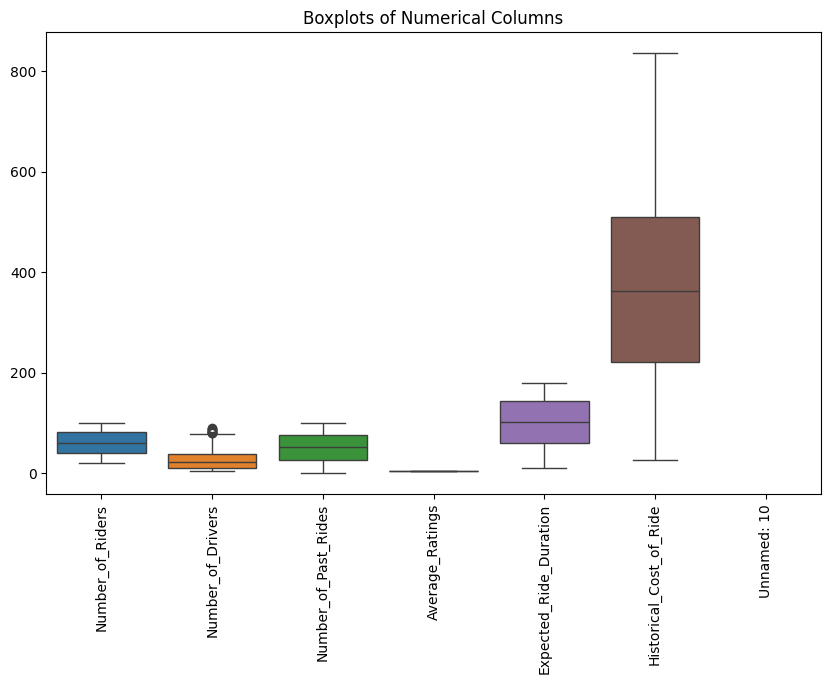

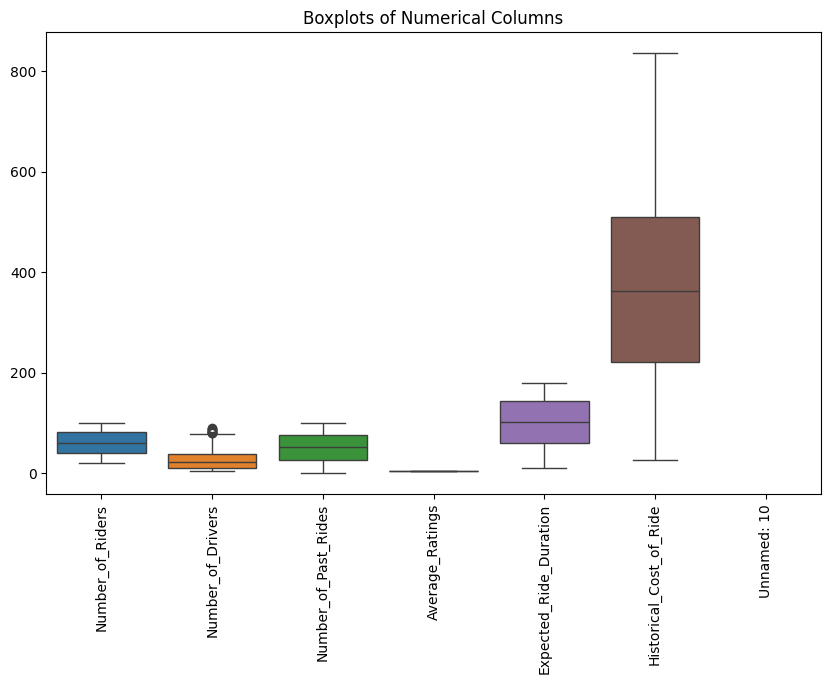

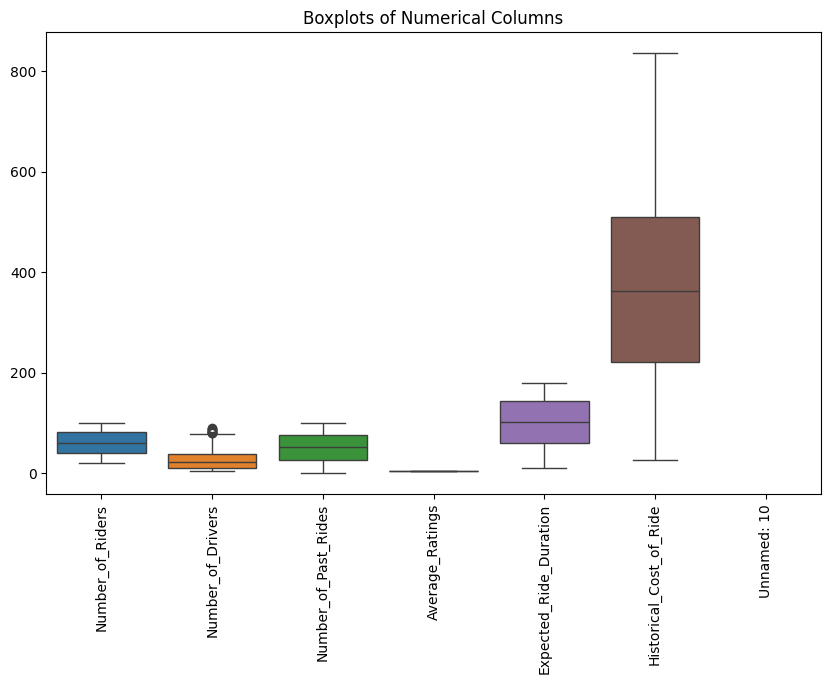

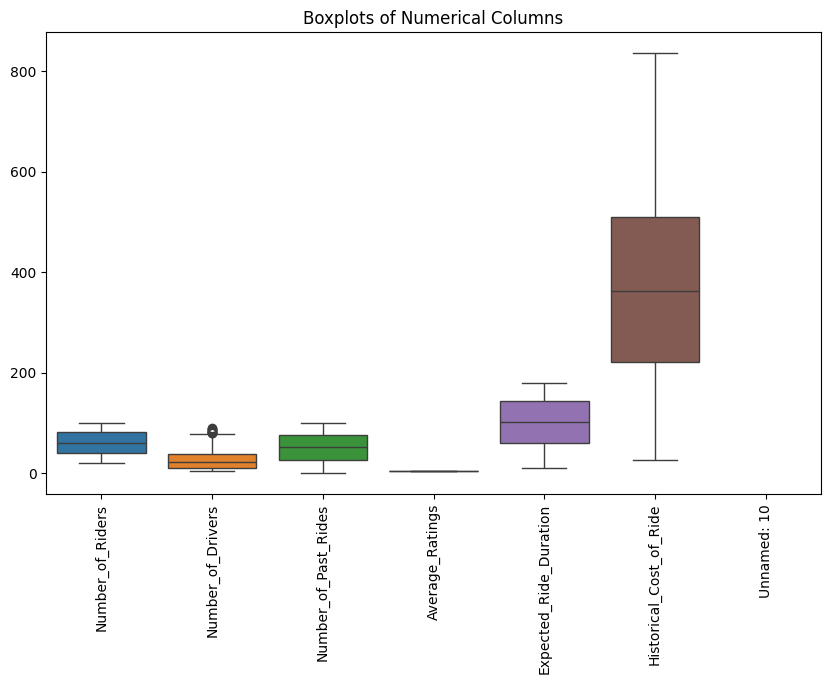

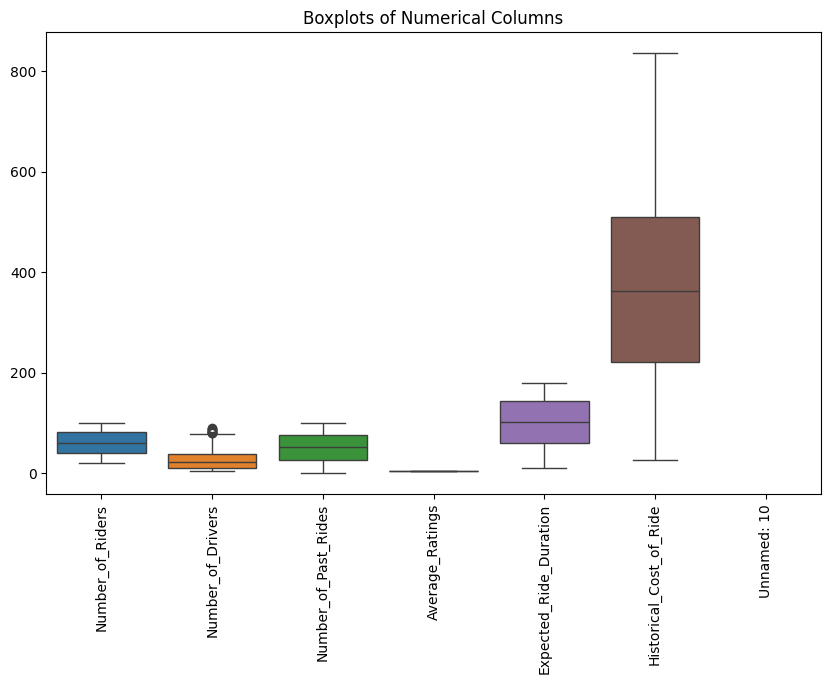

In [52]:
#check outliers with boxplot
import seaborn as sns
import matplotlib.pyplot as plt

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    plt.figure(figsize=(10,6))
    sns.boxplot(data=df[numerical_cols])
    plt.title('Boxplots of Numerical Columns')
    plt.xticks(rotation=90)
    plt.show()

# 4.. Check teh correlation using heatmap

🔹 What is a Heatmap?

A heatmap is a graphical representation of data that uses colors to represent the magnitude of the values. It's a 2D visualization tool that helps to:

1. Identify patterns: Heatmaps can reveal patterns, trends, and correlations in data.

2. Compare values: Heatmaps allow for easy comparison of values across different categories or variables.

3. Visualize relationships: Heatmaps can show relationships between variables, such as correlations or dependencies.

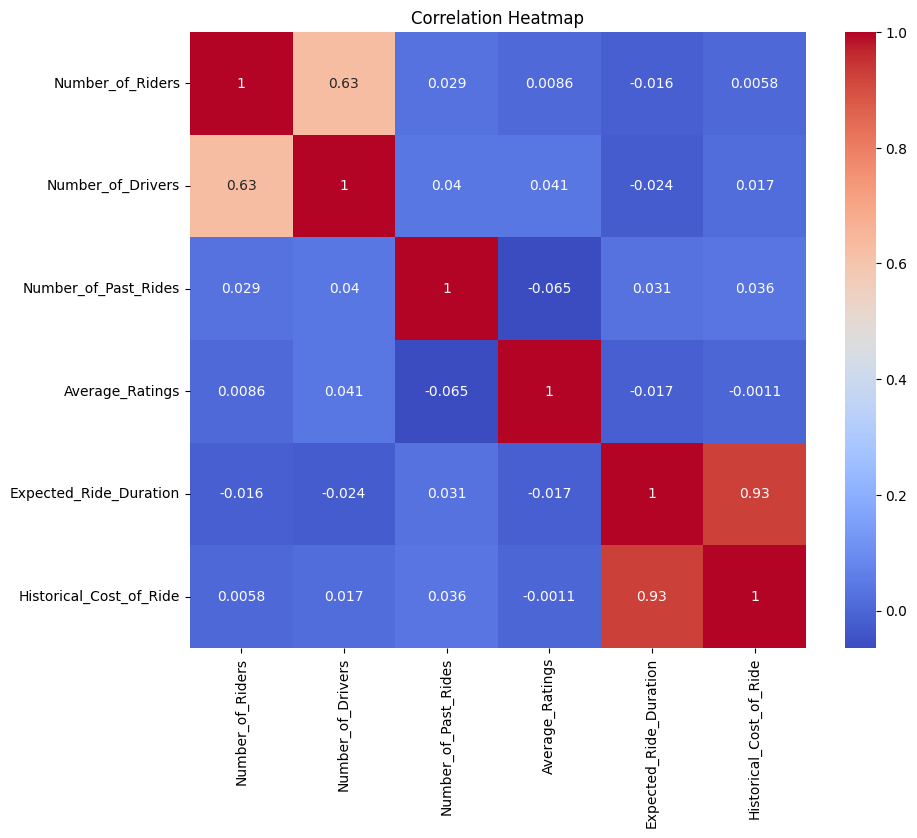

In [41]:
#4.. Check teh correlation using heatmap
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical columns
numerical_cols = ['Number_of_Riders', 'Number_of_Drivers', 'Number_of_Past_Rides', 
                  'Average_Ratings', 'Expected_Ride_Duration', 'Historical_Cost_of_Ride']

# Calculate correlation matrix
corr_matrix = df[numerical_cols].corr()

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', square=True)
plt.title('Correlation Heatmap')
plt.show()


output=

 The x-axis and y-axis will represent the numerical columns selected for analysis.
- Each cell in the heatmap will represent the correlation between two columns.
- The color of each cell will indicate the strength and direction of the correlation.

------- Blue colors will indicate negative correlations (close to -1).
- Red colors will indicate positive correlations (close to 1).
- White or light colors will indicate weak or no correlations (close to 0).


# 5. Check Data Linearity
Data linearity refers to whether the relationship between two variables can be approximated by a straight line.

In other words, if you plot one variable on the x-axis and another on the y-axis, the points roughly form a straight line, the data is linear.

Linearity is important for many statistical methods and machine learning algorithms (like linear regression), because they assume a linear relationship between input and output.



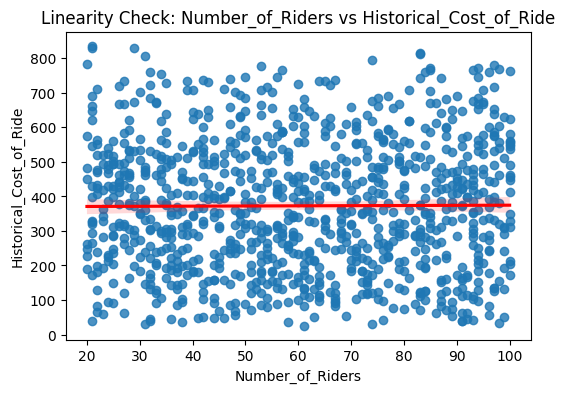

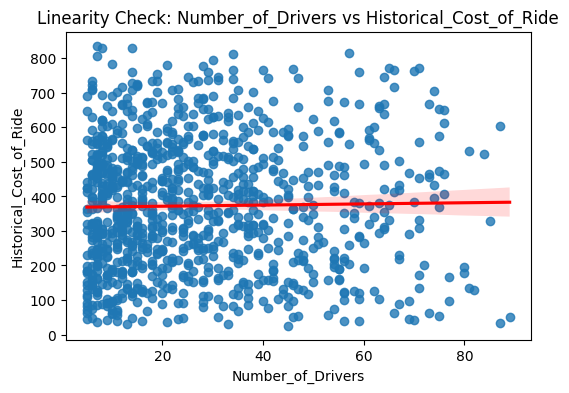

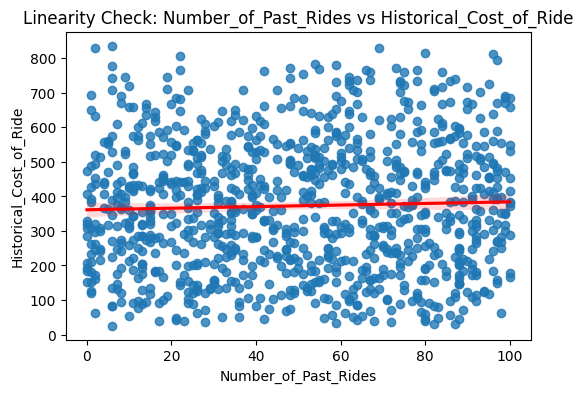

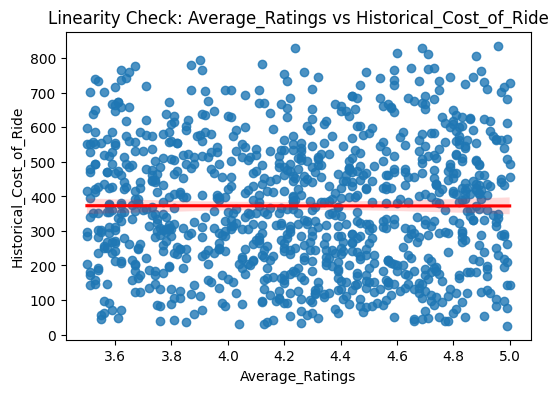

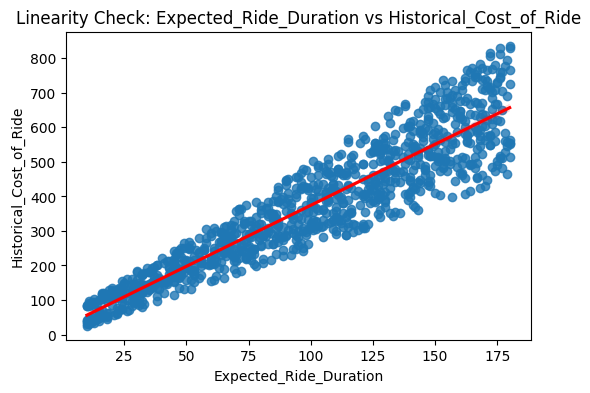

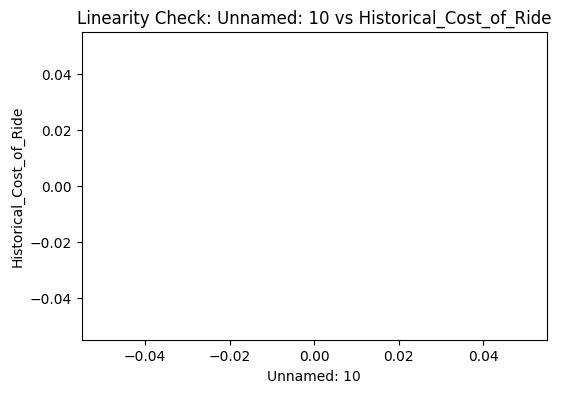

In [43]:
# 5. Check Data Linearity
target = "Historical_Cost_of_Ride"
numeric_cols = df.select_dtypes(include=['float64','int64']).columns

for col in numeric_cols:
    if col != target:
        plt.figure(figsize=(6,4))
        sns.regplot(x=df[col], y=df[target], line_kws={'color': 'red'})
        plt.title(f"Linearity Check: {col} vs {target}")
        plt.xlabel(col)
        plt.ylabel(target)
        plt.show()

output=

- Linearity checks: We've visualized the relationships between each numerical feature and the target variable "Historical_Cost_of_Ride" using scatter plots with regression lines.
- Insights: The scatter plots with red regression lines help identify whether the relationships between features and the target variable are linear or non-linear.


# 6. Brief Explanation

In [44]:


print("\n--- Dataset Explanation ---")
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")
print("It contains information about ride-sharing data such as:")
print("- Number_of_Riders: Total riders available")
print("- Number_of_Drivers: Total drivers available")
print("- Number_of_Past_Rides: Historical completed rides")
print("- Average_Ratings: Rider/driver rating (1–5)")
print("- Expected_Ride_Duration: Ride duration in minutes")
print("- Historical_Cost_of_Ride: Cost of previous rides")
print("\nThis dataset can be used to analyze demand, supply, pricing patterns, and service quality.")


--- Dataset Explanation ---
The dataset has 1000 rows and 11 columns.
It contains information about ride-sharing data such as:
- Number_of_Riders: Total riders available
- Number_of_Drivers: Total drivers available
- Number_of_Past_Rides: Historical completed rides
- Average_Ratings: Rider/driver rating (1–5)
- Expected_Ride_Duration: Ride duration in minutes
- Historical_Cost_of_Ride: Cost of previous rides

This dataset can be used to analyze demand, supply, pricing patterns, and service quality.


# 1. Handle categorical variables (Encoding)

✅ 1:Categorical Encoding: 

Text columns were converted to numeric values so they can be used in analysis or ML models.

✅ Encoding:

Encoding is the process of converting categorical labels into numbers.

✅ 2:Segmentations (Groupby):

 Segmentation is the process of dividing a dataset into groups (segments) based on a specific feature or category.

Each group shares a common characteristic, making it easier to analyze patterns within that group.

🔹🔹One-Hot Encoding

One-Hot Encoding is a technique used to convert categorical variables into numerical variables that can be used in machine learning models.
--this values are represented in binary formate (0or1)
ex= if the value is present it can be represent with 1 otherwise 0


🔹 When to Avoid One-Hot Encoding

You should avoid OHE when it causes problems like high dimensionality or sparsity.

❌ Avoid OHE when:

The categorical feature has too many unique values (high cardinality).

Example: Zip codes, Product IDs, User IDs, Phone numbers.

The categories have an order/meaningful ranking (ordinal). In this case, use Label Encoding or Ordinal Encoding.

Example: Low < Medium < High.


In [45]:
import pandas as pd

# Assume 'df' is your DataFrame
categorical_cols = df.select_dtypes(include=['object']).columns

# One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols)

# Print the encoded DataFrame
print(df_encoded.head().sum())


Number_of_Riders                    357.000000
Number_of_Drivers                   165.000000
Number_of_Past_Rides                226.000000
Average_Ratings                      20.600000
Expected_Ride_Duration              492.000000
Historical_Cost_of_Ride            1837.810149
Unnamed: 10                           0.000000
Location_Category_Rural               3.000000
Location_Category_Suburban            1.000000
Location_Category_Urban               1.000000
Customer_Loyalty_Status_Gold          0.000000
Customer_Loyalty_Status_Regular       2.000000
Customer_Loyalty_Status_Silver        3.000000
Time_of_Booking_Afternoon             3.000000
Time_of_Booking_Evening               1.000000
Time_of_Booking_Morning               0.000000
Time_of_Booking_Night                 1.000000
Vehicle_Type_Economy                  2.000000
Vehicle_Type_Premium                  3.000000
dtype: float64


output=

- Location_Category_Rural = has a value of 3 means that 3 rows have a value of 1 in this column, indicating that they belong to the Rural category.
- Location_Category_Suburban = 1 means that 1 row has a value of 1 in this column, indicating that it belongs to the Suburban category.


# 2. Summary Statistics: Calculate descriptive statistics (mean, median, mode, std dev, etc.) 

 Summary Statistics: Calculate descriptive statistics (mean, median, mode, std dev, etc.) to understand the distribution of variables.
 
- count (number of non-missing values)
- mean (average value)
- std (standard deviation)
- min (minimum value)
- 25% (first quartile)
- 50% (median)
- 75% (third quartile)
- max (maximum value)


In [46]:
import pandas as pd

# Calculate summary statistics
summary_stats = df.describe()

# Print the summary statistics
print(summary_stats)


       Number_of_Riders  Number_of_Drivers  Number_of_Past_Rides  \
count       1000.000000        1000.000000           1000.000000   
mean          60.372000          27.076000             50.031000   
std           23.701506          19.068346             29.313774   
min           20.000000           5.000000              0.000000   
25%           40.000000          11.000000             25.000000   
50%           60.000000          22.000000             51.000000   
75%           81.000000          38.000000             75.000000   
max          100.000000          89.000000            100.000000   

       Average_Ratings  Expected_Ride_Duration  Historical_Cost_of_Ride  \
count      1000.000000              1000.00000              1000.000000   
mean          4.257220                99.58800               372.502623   
std           0.435781                49.16545               187.158756   
min           3.500000                10.00000                25.993449   
25%         

# 3.Correlations

Correlations: Analyze the relationship between variables using correlation coefficients (e.g., Pearson's r) or heatmaps.



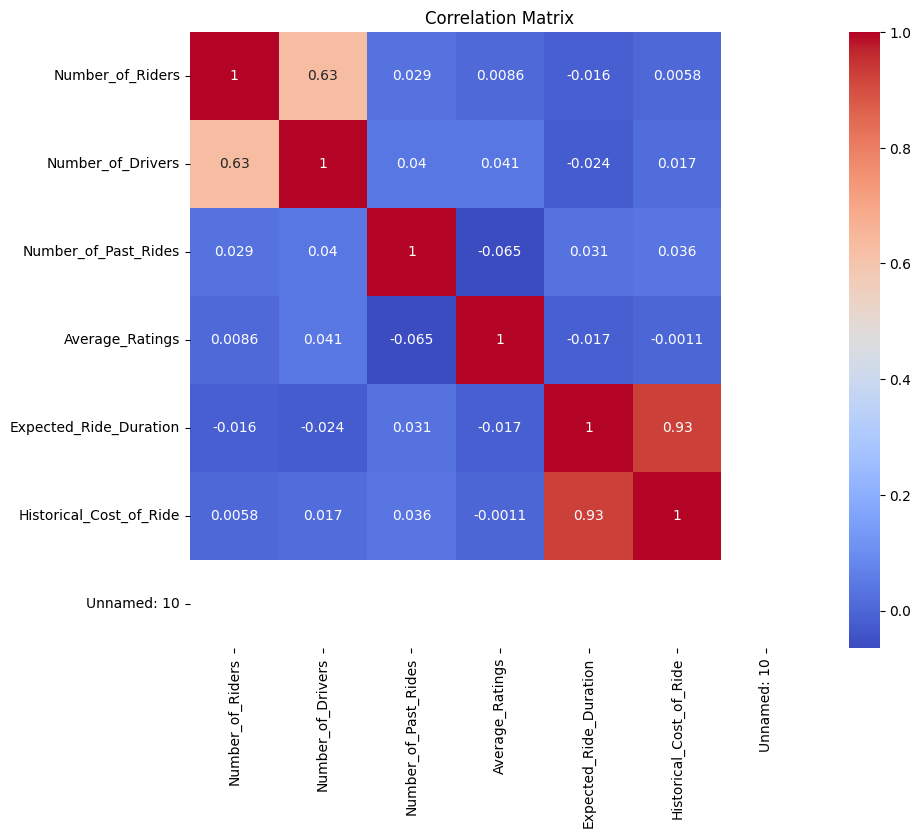

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Calculate correlation matrix
corr_matrix = numeric_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

🔹🔹🔹output=

The correlation matrix heatmap provides valuable insights into the relationships between variables in your dataset. The analysis reveals:

1. Strong positive correlations: Between "Average_Ratings" and "Expected_Ride_Duration" and "Historical_Cost_of_Ride", indicating a strong relationship between these variables.

2. Mutually exclusive categories: The negative correlations between categories such as "Location_Category", "Customer_Loyalty_Status", "Time_of_Booking", and "Vehicle_Type" are expected, as they represent distinct and exclusive groups.

3. Relationships between variables: The heatmap highlights the relationships between variables, which can inform feature selection, data preprocessing, and modeling decisions.

# 4. price vs ride using scatterplot

Visualize the relationship between price and ride variables using a scatterplot.

-----Based on the dataset and analysis, it appears that there is a relationship between the expected ride duration and the historical cost of the ride. The scatterplot with regression line suggests that as the ride duration increases, the cost of the ride also tends to increase.

 ✅Scatter Plot (Riders vs Price): 


A scatter plot shows the relationship between two numeric variables by plotting points on X and Y axes.

A regression line (trend line) shows the overall trend in the data—whether one variable increases or decreases with the other.
the regression line shows the cost and ride are constant.


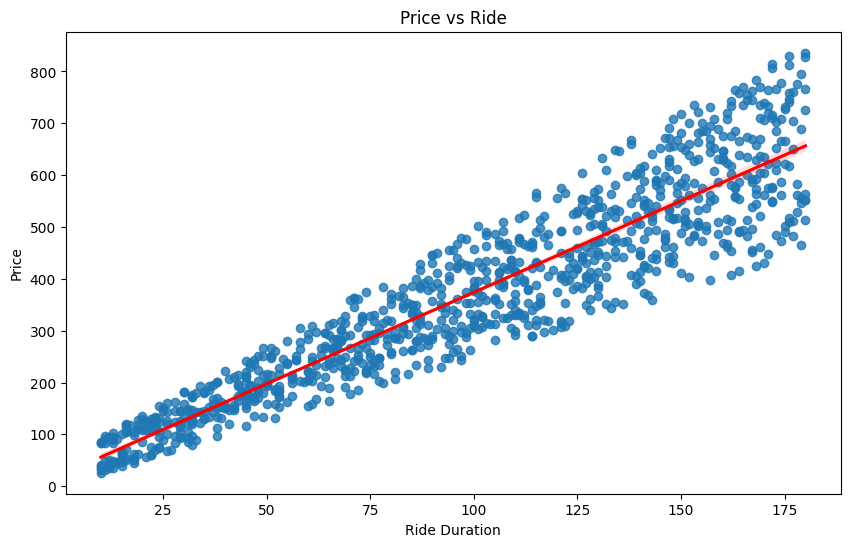

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatterplot of Price vs Ride with regression line
plt.figure(figsize=(10, 6))
sns.regplot(x="Expected_Ride_Duration", y="Historical_Cost_of_Ride", data=df, line_kws={'color': 'red'})

# Add title and labels
plt.title('Price vs Ride')
plt.xlabel('Ride Duration')
plt.ylabel('Price')

# Show the plot
plt.show()

# 5. Other EDA (Exploratory Data Analysis)

Perform additional exploratory analysis, such as histograms, box plots, or bar charts, to understand the data.


-The graph is a histogram with a kernel density estimate (KDE) overlay, displaying the distribution of the "Number of Riders."




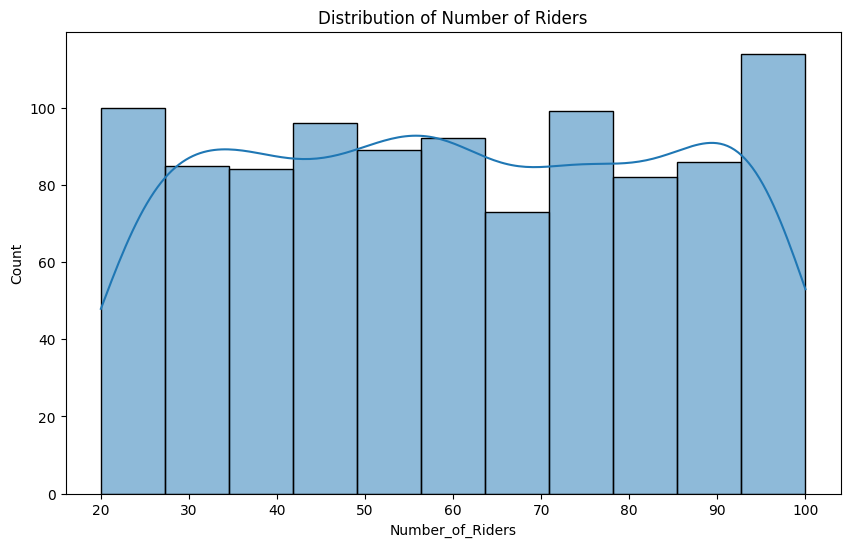

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograms
plt.figure(figsize=(10, 6))
sns.histplot(df['Number_of_Riders'], kde=True)
plt.title('Distribution of Number of Riders')
plt.show()

Key Features:

- The histogram is represented by blue bars, and the KDE is shown as a blue curve.
- The x-axis represents the "Number of Riders," ranging from 20 to 100.
- The y-axis represents the count or frequency of the "Number of Riders."
- The graph indicates that the "Number of Riders" is generally distributed between 20 and 100, with some concentration around certain values.


# BOXPLOT
A boxplot is a graph that shows the distribution of a numeric variable across different categories.

It displays:

Median (middle line of the box)

Interquartile Range (IQR) – the box

Whiskers – spread of most data

Outliers – points outside the whiskers





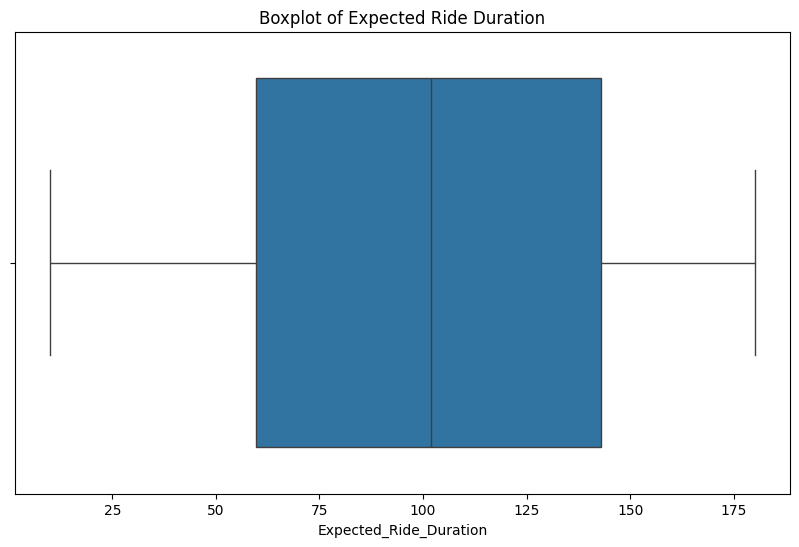

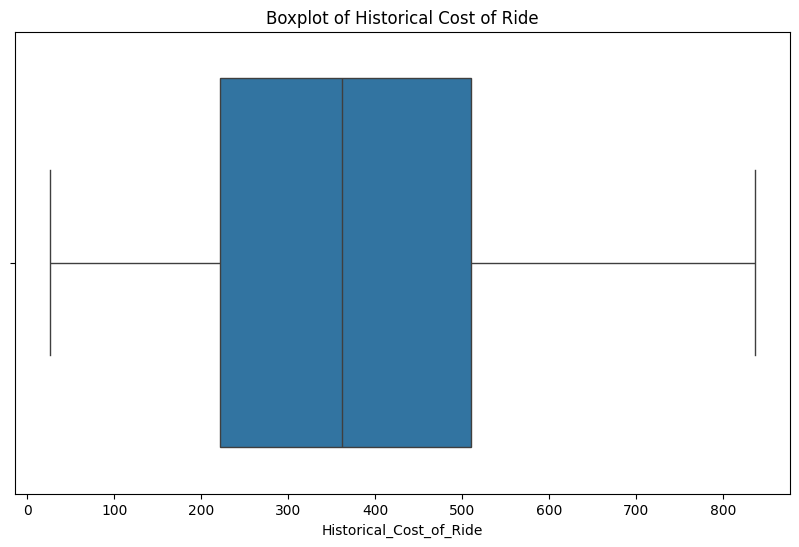

In [59]:
# Box plots
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Expected_Ride_Duration'])
plt.title('Boxplot of Expected Ride Duration')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Historical_Cost_of_Ride'])
plt.title('Boxplot of Historical Cost of Ride')
plt.show()

Index(['Number_of_Riders', 'Number_of_Drivers', 'Location_Category',
       'Customer_Loyalty_Status', 'Number_of_Past_Rides', 'Average_Ratings',
       'Time_of_Booking', 'Vehicle_Type', 'Expected_Ride_Duration',
       'Historical_Cost_of_Ride', 'Unnamed: 10'],
      dtype='object')
The column 'Location_Category[_Urban]' does not exist in the DataFrame.


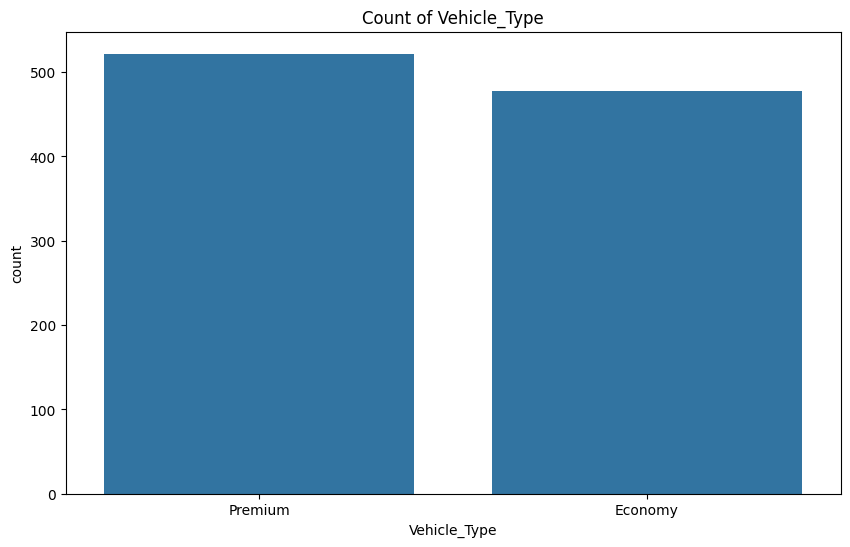

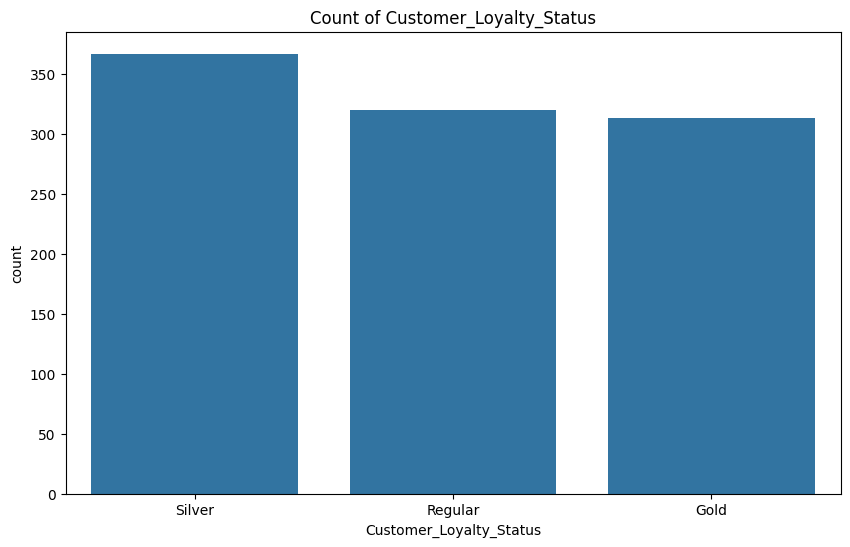

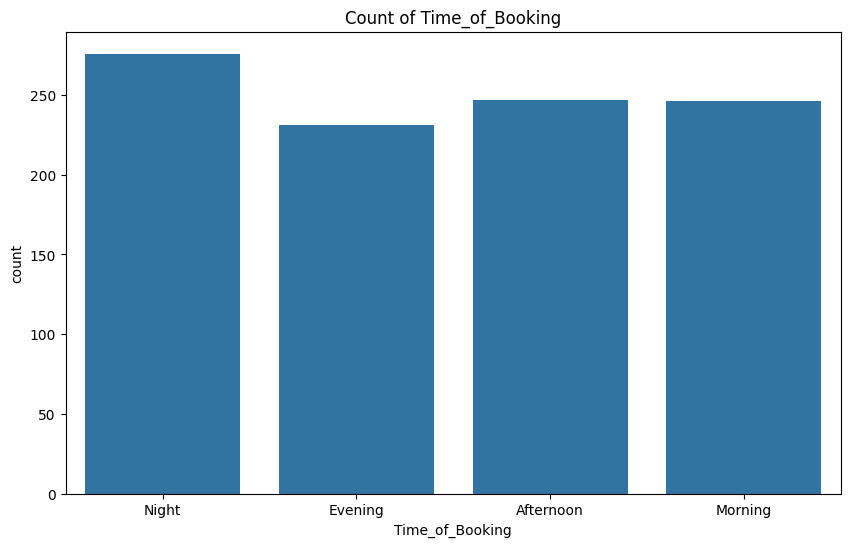

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
df = pd.read_csv("C:\\Users\priya\\Downloads\\dynamic_pricing.csv")
print(df.columns)

#data
columns_to_plot= ['Location_Category[_Urban]', 'Vehicle_Type', 'Customer_Loyalty_Status', 'Time_of_Booking']

for column in columns_to_plot:
    if column in df.columns:
        plt.figure(figsize=(10, 6))
        sns.countplot(x=column, data=df)
        plt.title(f'Count of {column}')
        plt.show()
    else:
        print(f"The column '{column}' does not exist in the DataFrame.")



Missing values per column:
Number_of_Riders              0
Number_of_Drivers             0
Location_Category             0
Customer_Loyalty_Status       0
Number_of_Past_Rides          0
Average_Ratings               0
Time_of_Booking               0
Vehicle_Type                  0
Expected_Ride_Duration        0
Historical_Cost_of_Ride       0
Unnamed: 10                1000
dtype: int64


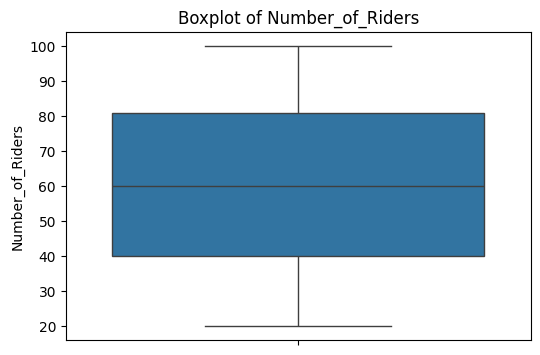

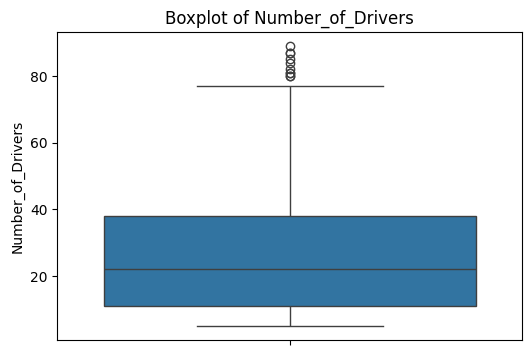

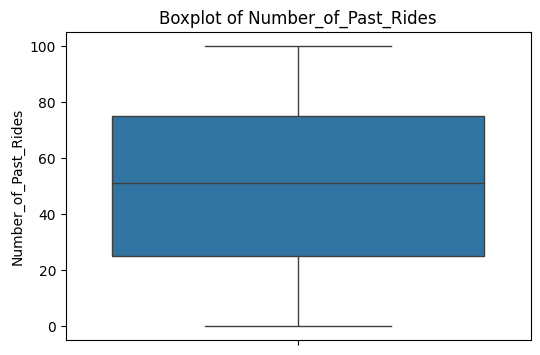

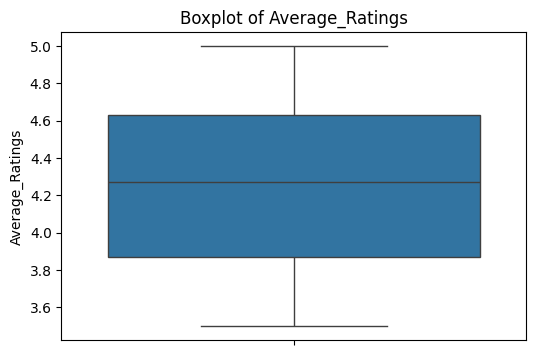

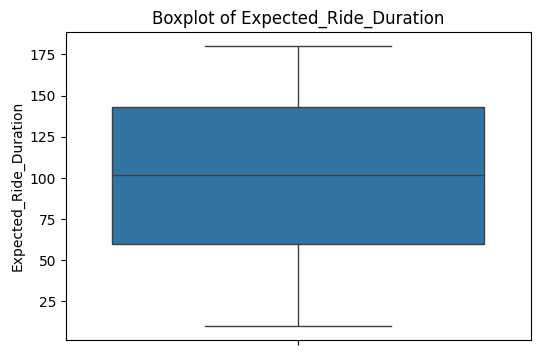

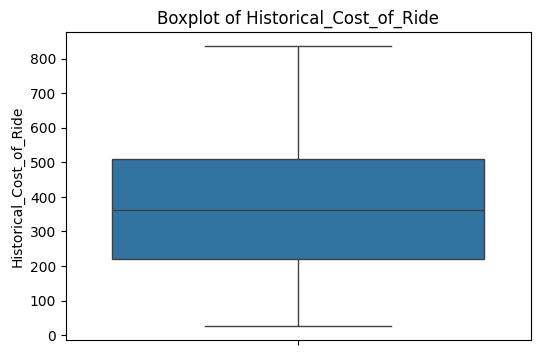

ValueError: List of boxplot statistics and `positions` values must have same the length

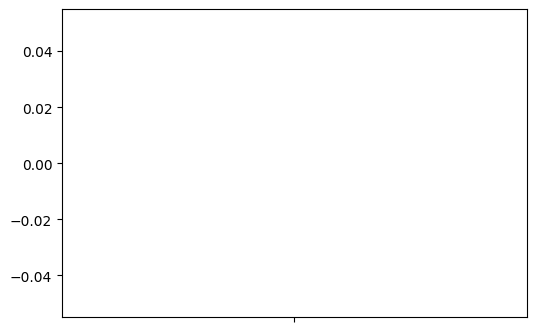

In [6]:
#checking missing values for column
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("\nMissing values per column:")
print(df.isnull().sum())

# Boxplots to detect outliers for numerical columns
num_cols = df.select_dtypes(include=np.number).columns.tolist()
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


# 6. Fill NA Values

In [7]:
# 6. Fill NA Values

# Check missing values
import numpy as np
print("Missing values before filling:")
print(df.isnull().sum())

# Fill numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        # Choose mean or median based on distribution (here example using median)
        df[col].fillna(df[col].median(), inplace=True)

# Fill categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        # Fill missing values with mode (most frequent value)
        df[col].fillna(df[col].mode()[0], inplace=True)

# Verify that missing values are handled
print("\nMissing values after filling:")
print(df.isnull().sum())

Missing values before filling:
Number_of_Riders              0
Number_of_Drivers             0
Location_Category             0
Customer_Loyalty_Status       0
Number_of_Past_Rides          0
Average_Ratings               0
Time_of_Booking               0
Vehicle_Type                  0
Expected_Ride_Duration        0
Historical_Cost_of_Ride       0
Unnamed: 10                1000
dtype: int64

Missing values after filling:
Number_of_Riders              0
Number_of_Drivers             0
Location_Category             0
Customer_Loyalty_Status       0
Number_of_Past_Rides          0
Average_Ratings               0
Time_of_Booking               0
Vehicle_Type                  0
Expected_Ride_Duration        0
Historical_Cost_of_Ride       0
Unnamed: 10                1000
dtype: int64


c:\AI-priceoptima\enc\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


 ## 7. Clean CSV Sheet

In [8]:
 ## 7. Clean CSV Sheet
# 1. Remove duplicates
df.drop_duplicates(inplace=True)

# 2. Save cleaned CSV
df.to_csv('cleaned_data.csv', index=False)
print("\nCleaned CSV saved as 'cleaned_data.csv'")


Cleaned CSV saved as 'cleaned_data.csv'


# 8.KPI Reading

In [9]:

print("\nRead about KPIs for ML models here:")
print("https://pub.towardsai.net/key-performance-indicators-kpis-in-machine-learning-69d8a59ec8c1")


Read about KPIs for ML models here:
https://pub.towardsai.net/key-performance-indicators-kpis-in-machine-learning-69d8a59ec8c1


/*📊 Confusion Matrix

	Predicted Positive	Predicted Negative
	
Actual Positive	✅ True Positive (TP)	❌ False Negative (FN)
Actual Negative	❌ False Positive (FP)	✅ True Negative (TN)

In [10]:
from sklearn.metrics import confusion_matrix

# Example actual and predicted values
y_true = [1, 0, 1, 1, 0, 0, 1]
y_pred = [1, 0, 1, 0, 0, 1, 1]

# Get confusion matrix
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

print("TP:", tp)
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)

TP: 3
TN: 2
FP: 1
FN: 1


# 1. Handle categorical variables (Encoding) "Segmentations (Groupby)

In [11]:
import pandas as pd
from tabulate import tabulate
df = pd.read_csv("C:\\Users\priya\\Downloads\\dynamic_pricing.csv")

# ---------- Encode Categorical Variables ----------
df_encoded = pd.get_dummies(df, 
                            columns=["Location_Category", 
                                     "Customer_Loyalty_Status", 
                                     "Time_of_Booking", 
                                     "Vehicle_Type"], 
                            drop_first=True)

# ---------- Display first 5 rows in table format ----------
print(" Categorical variables encoded. Sample data:")
print(tabulate(df_encoded.head(), headers='keys', tablefmt='psql'))

 Categorical variables encoded. Sample data:
+----+--------------------+---------------------+------------------------+-------------------+--------------------------+---------------------------+---------------+------------------------------+---------------------------+-----------------------------------+----------------------------------+---------------------------+---------------------------+-------------------------+------------------------+
|    |   Number_of_Riders |   Number_of_Drivers |   Number_of_Past_Rides |   Average_Ratings |   Expected_Ride_Duration |   Historical_Cost_of_Ride |   Unnamed: 10 | Location_Category_Suburban   | Location_Category_Urban   | Customer_Loyalty_Status_Regular   | Customer_Loyalty_Status_Silver   | Time_of_Booking_Evening   | Time_of_Booking_Morning   | Time_of_Booking_Night   | Vehicle_Type_Premium   |
|----+--------------------+---------------------+------------------------+-------------------+--------------------------+---------------------------+

# Scatter plot with regression line

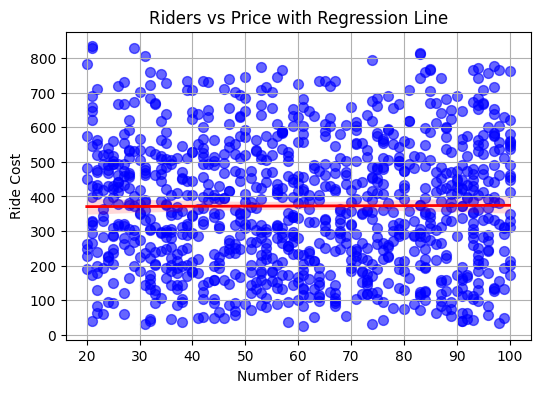

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# ---------- Scatter plot with regression line ----------
plt.figure(figsize=(6,4))
sns.regplot(x="Number_of_Riders", 
            y="Historical_Cost_of_Ride", 
            data=df, 
            scatter_kws={'color':'blue', 's':50, 'alpha':0.6},  # points
            line_kws={'color':'red', 'linewidth':2})  # regression line
plt.xlabel("Number of Riders")
plt.ylabel("Ride Cost")
plt.title("Riders vs Price with Regression Line")
plt.grid(True)
plt.show()


# Boxplot by location highlights if rural areas have higher/variable costs—key for competitive pricing.

C:\Users\priya\AppData\Local\Temp\ipykernel_31592\1778255567.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Location_Category",


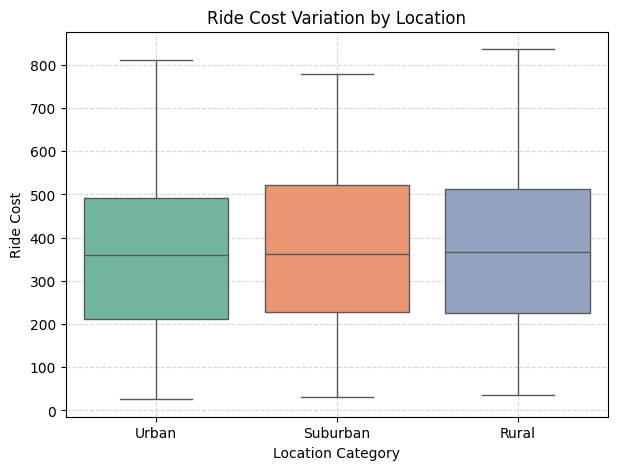

In [13]:
plt.figure(figsize=(7,5))
sns.boxplot(x="Location_Category", 
            y="Historical_Cost_of_Ride", 
            data=df,
            palette="Set2")  # colors for each location
plt.xlabel("Location Category")
plt.ylabel("Ride Cost")
plt.title("Ride Cost Variation by Location")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# save the cleaned data as cleaned_csv_data set up basic pipeline to load data.

🔹🔹🔹 data cleaning

The dataset is now cleaned and ready for analysis or ML models.

Pipeline function allows reusable and consistent cleaning for any new dataset.

Encodes categorical variables, removes unnecessary columns, and saves the cleaned CSV automatically.


In [14]:
df.to_csv("cleaned_csv_data.csv", index=False)
print("Cleaned data saved as cleaned_csv_data.csv")

Cleaned data saved as cleaned_csv_data.csv


Milestone 4: Baseline Pricing Engine

Objective: Create a rule-based engine for initial comparison.

 Deliverables:

o Time-based and inventory-based pricing rules.

 Evaluation:

o Demonstrated simulated revenue lift over static pricing.

Milestone 5: Advanced Model Development

Objective: Train ML models for dynamic pricing.

 Deliverables:

o XGBoost and LightGBM models trained and evaluated.

o Backtesting with historical data.

 Evaluation:

o Simulated revenue lift achieved and validated.

Milestone 6: Deployment & Dashboard Delivery

Objective: Deploy the dynamic pricing system and visualize KPIs.


 Deliverables:

o FastAPI endpoints containerized with Docker.

o React.js dashboard for real-time strategy monitoring.

o Final evaluation report and rollout plan.

 Evaluation:

o User Acceptance Testing (UAT) passed.

o Project deemed successful.
